# Fine-Tuning Dataset Preparation
Combine, remove duplicates, and cluster proteins based on sequence similarity for fine-tuning training/test set. 
- Datasets: BindingDB (Kd, IC50), ChEMBL (Kd, IC50), SAIR

## Configuration

In [40]:
import os
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
bdb_kd_csv = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_saved_pdb.csv"
bdb_ic50_csv = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_IC50_with_pdb_val_saved_pdb.csv"
chembl_kd_csv = "/scratch/yunmin/data/graph/chembl/filtered/chembl_Kd_with_pdb_val.csv"
chembl_ic50_csv = "/scratch/yunmin/data/graph/chembl/filtered/chembl_IC50_with_pdb_val.csv"
sair_csv = "/scratch/yunmin/data/graph/sair/filtered/sair_pIC50_all_tight_val.csv"

## Load data

In [4]:
def load_data(input_csv):
    print(f"Loading data from {input_csv}...")
    df = pd.read_csv(input_csv)
    initial_rows = len(df)

    print(f"\n✅ Loaded {initial_rows:,} rows")
    print(f"  - Columns: {df.columns.tolist()}")
    if 'protein_key' in df.columns:
        print(f"  - Unique proteins: {df['protein_key'].nunique():,}")
    elif 'protein' in df.columns:
        print(f"  - Unique proteins: {df['protein'].nunique():,}")
    print(f"  - Targets: {(df['target_type'] == 'target').sum():,}")
    print(f"  - Off-targets: {(df['target_type'] == 'off_target').sum():,}")
    print("=" * 80)
    return df

bdb_kd_df = load_data(bdb_kd_csv)
bdb_ic50_df = load_data(bdb_ic50_csv)
chembl_kd_df = load_data(chembl_kd_csv)
chembl_ic50_df = load_data(chembl_ic50_csv)
sair_df = load_data(sair_csv)

Loading data from /scratch/yunmin/data/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_saved_pdb.csv...

✅ Loaded 28,033 rows
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status']
  - Unique proteins: 445
  - Targets: 7,841
  - Off-targets: 20,192
Loading data from /scratch/yunmin/data/graph/bdb/filtered/bindingdb_IC50_with_pdb_val_saved_pdb.csv...

✅ Loaded 515,395 rows
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_IC50_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status']
  - Unique proteins: 1,108
  - Targets: 252,846
  -

## Concatenate datasets

### BindingDB/ChEMBL Kd+IC50

In [5]:
def merge_assay_df(df1, df2):
    df1 = df1.copy()
    df2 = df2.copy()
    df1["assay_type"] = "Kd"
    df2["assay_type"] = "IC50"

    df1["original_assay_nM"] = df1["original_Kd_nM"]
    df2["original_assay_nM"] = df2["original_IC50_nM"]
    df1 = df1.drop(columns=["original_Kd_nM"])
    df2 = df2.drop(columns=["original_IC50_nM"])

    print(f"Merging dataframes with {len(df1):,} and {len(df2):,} rows...")
    merged_df = pd.concat([df1, df2], ignore_index=True)

    print(f"  - Columns: {merged_df.columns.tolist()}")
    if 'protein_key' in merged_df.columns:
        print(f"  - Unique proteins: {merged_df['protein_key'].nunique():,}")
    elif 'protein' in merged_df.columns:
        print(f"  - Unique proteins: {merged_df['protein'].nunique():,}")
    print(f"  - Targets: {(merged_df['target_type'] == 'target').sum():,}")
    print(f"  - Off-targets: {(merged_df['target_type'] == 'off_target').sum():,}")
    print(f"  - Kd: {(merged_df['assay_type'] == 'Kd').sum():,}")
    print(f"  - IC50: {(merged_df['assay_type'] == 'IC50').sum():,}")
    print("=" * 80)
    return merged_df

bdb_df = merge_assay_df(bdb_kd_df, bdb_ic50_df)
chembl_df = merge_assay_df(chembl_kd_df, chembl_ic50_df)

Merging dataframes with 28,033 and 515,395 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM']
  - Unique proteins: 1,222
  - Targets: 260,687
  - Off-targets: 282,741
  - Kd: 28,033
  - IC50: 515,395
Merging dataframes with 75,173 and 576,831 rows...
  - Columns: ['protein_key', 'target_chembl_id', 'component_id', 'accession', 'target_name', 'target_source', 'target_tax_id', 'sequence', 'sequence_length', 'ligand_chembl_id', 'molregno', 'ligand_inchikey', 'canonical_smiles', 'compound_name', 'representative_assay_nM', 'target_type', 'n_measurements', 'assay_chembl_ids', 'doc_chembl_ids', 'doi', 'pubmed_id', 'pdb_ids', 'assay_type', 'original_assay_nM']
  - Unique proteins: 1,728
  - Targets: 269,594
  

In [6]:
# Deduplicate dataframes
key_cols = [
    "protein_key",
    "uniprot_id",
    "ligand_inchikey",
    "ligand_het_id",
    "target_type",
]

print("Deduplicating BindingDB dataframe...")
print(f"Before deduplication: {len(bdb_df):,} rows")
bdb_df_dedup = bdb_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(bdb_df_dedup):,} rows ({len(bdb_df) - len(bdb_df_dedup):,} duplicates removed)\n")

key_cols = [
    "protein_key",
    "accession",
    "ligand_inchikey",
    "ligand_chembl_id",
    "target_type",
]
print("Deduplicating ChEMBL dataframe...")
print(f"Before deduplication: {len(chembl_df):,} rows")
chembl_df_dedup = chembl_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(chembl_df_dedup):,} rows ({len(chembl_df) - len(chembl_df_dedup):,} duplicates removed)\n")

Deduplicating BindingDB dataframe...
Before deduplication: 543,428 rows
After deduplication: 533,126 rows (10,302 duplicates removed)

Deduplicating ChEMBL dataframe...
Before deduplication: 652,004 rows
After deduplication: 649,204 rows (2,800 duplicates removed)



### Dataset preview

In [7]:
bdb_df_dedup.head()

,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,representative_assay_nM,target_type,curation_source,doi,complex_pdb_id,valid_pdb_id,validation_status,assay_type,original_assay_nM
0,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,XPRDUGXOWVXZLL-UHFFFAOYSA-N,COc1cccc(c1)-c1ccc(NC(=O)C2=C(CCC2)C(O)=O)c(F)c1,2-{[2-fluoro-4-(3-methoxyphenyl)phenyl]carbamo...,D5H,3.400000e+00,target,ChEMBL,10.1016/j.ejmech.2023.115225,5Y1J,NaN,No UniProt match,Kd,3.4
1,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,RNAHYXBPBZSDMH-CABZIAIVSA-N,CC(C)C(=O)[C@H](C)[C@H](O)[C@@]1(C)[C@H](C(C)=...,CHEMBL5398242,NaN,1.180000e+04,off_target,ChEMBL,10.1039/d3md00036b,NaN,NaN,No PDB IDs,Kd,11800
2,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,FAKRSMQSSFJEIM-RQJHMYQMSA-N,C[C@H](CS)C(=O)N1CCC[C@H]1C(O)=O,(2S)-1-[(2S)-2-methyl-3-sulfanylpropanoyl]pyrr...,X8Z,4.350000e+05,off_target,ChEMBL,10.1021/acs.jmedchem.3c00171,"4C1D,4C1F,4C1H,4DPR,3LUS,6V61,5ZIO,8SKO,4EXS,2...",5ZIO,Valid,Kd,435000
3,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,KCYKSHQJSXQPFL-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)Cc1cccs1)C1CCCCN1,CHEMBL5430990,NaN,8.366600e+05,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,1400000; 500000
4,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,CAGUYJHZPXSDRT-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)c1cccs1)C1CCCCN1,CHEMBL5403793,NaN,2.000000e+06,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,2000000


In [ ]:
chembl_df_dedup.head()

,protein_key,target_chembl_id,component_id,accession,target_name,target_source,target_tax_id,sequence,sequence_length,ligand_chembl_id,...,representative_assay_nM,target_type,n_measurements,assay_chembl_ids,doc_chembl_ids,doi,pubmed_id,pdb_ids,assay_type,original_assay_nM
0,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL857,...,0.00001,target,1,CHEMBL3369575,CHEMBL3351755,10.1021/jm500325k,24913411.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,1e-05
1,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL280317,...,11.00000,target,1,CHEMBL3369575,CHEMBL3351755,10.1021/jm500325k,24913411.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,11.0
2,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL477,...,168000.00000,off_target,1,CHEMBL2210840,CHEMBL2202973,10.1016/j.bmcl.2012.09.088,23084893.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,168000.0
3,CHEMBL_CHEMBL1075092_COMP_4396_Homo_sapiens,CHEMBL1075092,4396,O75311,Glycine receptor subunit alpha-3,Homo sapiens,9606,MAHVRHFRTLVSGFYFWEAALLLSLVATKETDSARSRSAPMSPSDF...,464,CHEMBL4070615,...,11.00000,target,1,CHEMBL3993231,CHEMBL3992512,10.1021/acs.jmedchem.6b01496,28001399.0,5CFB;5TIN;5TIO;5VDH;5VDI;9BU2;9BU3;9BVH;9BVJ;9...,Kd,11.0
4,CHEMBL_CHEMBL1075092_COMP_4396_Homo_sapiens,CHEMBL1075092,4396,O75311,Glycine receptor subunit alpha-3,Homo sapiens,9606,MAHVRHFRTLVSGFYFWEAALLLSLVATKETDSARSRSAPMSPSDF...,464,CHEMBL4081234,...,20000.00000,off_target,1,CHEMBL3993231,CHEMBL3992512,10.1021/acs.jmedchem.6b01496,28001399.0,5CFB;5TIN;5TIO;5VDH;5VDI;9BU2;9BU3;9BVH;9BVJ;9...,Kd,20000.0


In [9]:
sair_df.head()

,entry_id,index,protein,sequence,sequence_length,ligand_smiles,pIC50,target_type,source,assay,family,description,vina_score_min,number_clashes,internal_energy,confidence_score,complex_plddt,complex_iplddt,ptm,iptm
0,654,0,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1OC(=O)N(c2nc(-c3cnc(N)nc3C(F)(F)F)cc(N3...,5.338621,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-10.7393,1.0,1.0,0.930772,0.916796,0.899851,0.967878,0.986674
1,674,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Nc1cc(C(F)(F)F)c(-c2cc(NC(CO)Cc3ccccc3)nc(N3CC...,5.209330,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-8.8858,1.0,1.0,0.921381,0.912904,0.847111,0.957527,0.955291
2,662,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Cn1c(=O)n(-c2ccc(C(C)(C)C#N)cc2)c2c3cc(-c4cnc5...,8.277862,target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-11.6466,1.0,1.0,0.928460,0.914086,0.895977,0.964621,0.985958
3,634,4,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,CC1C(c2cccnc2)OC(=O)N1c1cc(-c2cnc(N)nc2C(F)(F)...,7.537602,target,BindingDB,na,kinase,US10202371,-10.7742,1.0,1.0,0.921728,0.910370,0.871247,0.957377,0.967160
4,660,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1[C@H](c2nccs2)OC(=O)N1c1cc(-c2cnc(N)nc2...,7.508638,target,BindingDB,na,kinase,US10202371,-10.3188,1.0,1.0,0.925128,0.912977,0.879408,0.965920,0.973730



  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM']
  - Columns: ['protein_key', 'accession', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'canonical_smiles', 'compound_name', ('ligand_het_id'), 'representative_assay_nM', 'target_type', 'doc_chembl_ids', 'doi', 'pdb_ids', ('valid_pdb_id', 'validation_status',) 'assay_type', 'original_assay_nM']
  - Columns: ['entry_id', 'index', 'protein', 'sequence', 'sequence_length', 'ligand_smiles', 'pIC50', 'target_type', 'source', 'assay', 'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm']
  
  -> 'protein_key' = 'entry_id'_'index'
    'protein' -> 'uniprot_id'
    ('target_name', 'target_source',) 'sequence', 'sequence_length', 
    ('ligand_inchikey'), 'ligand_smiles', ('ligand_name', 'ligand_het_id',)
    'pIC50' -> 'representative_asssay_nM' (unit conversion to nM), 'target_type',
    'source' -> 'curation_source', 
    drop 'assay', 
    'doi', 'complex_pdb_id', 'valid_pdb_id' ('protein_key'), 
    'validation_status' -> all True, 
    'assay_type' -> all IC50, 
    'original_assay_nM' -> 'pIC50'
    after follows sair original columns: 'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm'


### BindingDB + ChEMBL

In [23]:
# Concatenate BindingDB and ChEMBL dataframes
bdb_df_copy = bdb_df_dedup.copy()
chembl_df_copy = chembl_df_dedup.copy()
chembl_df_copy = chembl_df_copy[[
    'protein_key', 'accession', 'target_name', 'target_source', 
    'sequence', 'sequence_length', 'ligand_inchikey', 'canonical_smiles', 
    'compound_name', 'representative_assay_nM', 'target_type', 
    'doi', 'pdb_ids', 'assay_type', 'original_assay_nM'
    ]]
# dropped 
# ['target_chembl_id', 'component_id', 'target_tax_id', 
# 'ligand_chembl_id', 'molregno', 
# 'n_measurements', 'assay_chembl_ids', 'doc_chembl_ids', 'pubmed_id']
chembl_df_copy = chembl_df_copy.rename(columns={
    "accession": "uniprot_id",
    "canonical_smiles": "ligand_smiles",
    "compound_name": "ligand_name",
    "pdb_ids": "complex_pdb_id",
    })

bdb_df_copy["data_source"] = "BindingDB"
chembl_df_copy["data_source"] = "ChEMBL"

print(f"Merging dataframes with {len(bdb_df_copy):,} and {len(chembl_df_copy):,} rows...")
bdb_chembl_df = pd.concat([bdb_df_copy, chembl_df_copy], ignore_index=True)
print(f"  - Columns: {bdb_chembl_df.columns.tolist()}")
print(f"  - Unique proteins: {bdb_chembl_df['protein_key'].nunique():,}")
n_tar = (bdb_chembl_df['target_type'] == 'target').sum()
n_off = (bdb_chembl_df['target_type'] == 'off_target').sum()
total = n_tar + n_off
print(f"  - Targets: {n_tar:,} ({n_tar/total*100:.2f}%)")
print(f"  - Off-targets: {n_off:,} ({n_off/total*100:.2f}%)")
n_Kd = (bdb_chembl_df['assay_type'] == 'Kd').sum()
n_IC50 = (bdb_chembl_df['assay_type'] == 'IC50').sum()
total = n_Kd + n_IC50
print(f"  - Kd: {n_Kd:,} ({n_Kd/total*100:.2f}%)")
print(f"  - IC50: {n_IC50:,} ({n_IC50/total*100:.2f}%)")
print("=" * 80)

# Deduplicate combined BindingDB + ChEMBL dataframe
key_cols = [
    "uniprot_id",
    "ligand_inchikey",
    "target_type",
    "sequence",
]

print("Deduplicating BindingDB + ChEMBL dataframe...")
print(f"Before deduplication: {len(bdb_chembl_df):,} rows")
bdb_chembl_df_dedup = bdb_chembl_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(bdb_chembl_df_dedup):,} rows ({len(bdb_chembl_df) - len(bdb_chembl_df_dedup):,} duplicates removed)\n")

dup_mask = bdb_chembl_df.duplicated(subset=key_cols, keep="first")
removed_df = bdb_chembl_df[dup_mask]
removed_unique_uniprot = removed_df["uniprot_id"].nunique()
removed_unique_ligand = removed_df["ligand_inchikey"].nunique()

print(f"Unique uniprot_id in removed rows: {removed_unique_uniprot:,}")
print(f"Unique ligand_inchikey in removed rows: {removed_unique_ligand:,}")

Merging dataframes with 533,126 and 649,204 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM', 'data_source']
  - Unique proteins: 2,950
  - Targets: 522,216 (44.17%)
  - Off-targets: 660,114 (55.83%)
  - Kd: 102,930 (8.71%)
  - IC50: 1,079,400 (91.29%)
Deduplicating BindingDB + ChEMBL dataframe...
Before deduplication: 1,182,330 rows
After deduplication: 811,972 rows (370,358 duplicates removed)

Unique uniprot_id in removed rows: 875
Unique ligand_inchikey in removed rows: 265,059


### BindingDB + ChEMBL + SAIR

In [87]:
bdb_chembl_df_dedup_copy = bdb_chembl_df_dedup.copy()
sair_df_copy = sair_df.copy()

sair_df_copy = sair_df_copy[[
    'entry_id', 'index', 'protein', 'sequence', 'sequence_length', 
    'ligand_smiles', 'pIC50', 'target_type', 'source',
    # sair original columns
    'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 
    'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm'
    ]]
# dropped: 'assay'
sair_df_copy = sair_df_copy.rename(columns={
    "protein": "uniprot_id",
    "source": "curation_source",
    })

sair_df_copy["data_source"] = "SAIR"

sair_df_copy["protein_key"] = sair_df_copy["entry_id"].astype(str) + "_" + sair_df_copy["index"].astype(str)
sair_df_copy["valid_pdb_id"] = sair_df_copy["protein_key"]
sair_df_copy["representative_assay_nM"] = sair_df_copy["pIC50"].apply(lambda x: 10 ** (9 - x) if pd.notnull(x) else x)
sair_df_copy["original_assay_nM"] = sair_df_copy["pIC50"].apply(lambda x: 10 ** (9 - x) if pd.notnull(x) else x)
sair_df_copy["validation_status"] = "Valid"
sair_df_copy["assay_type"] = "IC50"

cols_to_tag = [
    'entry_id', 'index', 'pIC50', 'family', 'description',
    'vina_score_min', 'number_clashes', 'internal_energy',
    'confidence_score', 'complex_plddt', 'complex_iplddt',
    'ptm', 'iptm'
]
rename_map = {col: f"{col} (SAIR)" for col in cols_to_tag if col in sair_df_copy.columns}
sair_df_copy = sair_df_copy.rename(columns=rename_map)

print(f"Merging dataframes with {len(bdb_chembl_df_dedup_copy):,} and {len(sair_df_copy):,} rows...")
total_df = pd.concat([bdb_chembl_df_dedup_copy, sair_df_copy], ignore_index=True)
print(f"  - Columns: {total_df.columns.tolist()}")
print(f"  - Unique proteins: {total_df['protein_key'].nunique():,}")
n_tar = (total_df['target_type'] == 'target').sum()
n_off = (total_df['target_type'] == 'off_target').sum()
total = n_tar + n_off
print(f"  - Targets: {n_tar:,} ({n_tar/total*100:.2f}%)")
print(f"  - Off-targets: {n_off:,} ({n_off/total*100:.2f}%)")
n_Kd = (total_df['assay_type'] == 'Kd').sum()
n_IC50 = (total_df['assay_type'] == 'IC50').sum()
total = n_Kd + n_IC50
print(f"  - Kd: {n_Kd:,} ({n_Kd/total*100:.2f}%)")
print(f"  - IC50: {n_IC50:,} ({n_IC50/total*100:.2f}%)")
print("=" * 80)

# Deduplicate combined BindingDB + ChEMBL + SAIR dataframe
key_cols = [
    "uniprot_id",
    "ligand_smiles",
    "target_type",
    "sequence",
]

print("Deduplicating BindingDB + ChEMBL + SAIR dataframe...")
print(f"Before deduplication: {len(total_df):,} rows")
total_df_dedup = total_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(total_df_dedup):,} rows ({len(total_df) - len(total_df_dedup):,} duplicates removed)\n")

dup_mask = total_df.duplicated(subset=key_cols, keep="first")
removed_df = total_df[dup_mask]
removed_unique_uniprot = removed_df["uniprot_id"].nunique()
removed_unique_ligand = removed_df["ligand_smiles"].nunique()

print(f"Unique uniprot_id in removed rows: {removed_unique_uniprot:,}")
print(f"Unique ligand_smiles in removed rows: {removed_unique_ligand:,}")

Merging dataframes with 811,972 and 75,409 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM', 'data_source', 'entry_id (SAIR)', 'index (SAIR)', 'pIC50 (SAIR)', 'family (SAIR)', 'description (SAIR)', 'vina_score_min (SAIR)', 'number_clashes (SAIR)', 'internal_energy (SAIR)', 'confidence_score (SAIR)', 'complex_plddt (SAIR)', 'complex_iplddt (SAIR)', 'ptm (SAIR)', 'iptm (SAIR)']
  - Unique proteins: 78,323
  - Targets: 407,628 (45.94%)
  - Off-targets: 479,753 (54.06%)
  - Kd: 80,658 (9.09%)
  - IC50: 806,723 (90.91%)
Deduplicating BindingDB + ChEMBL + SAIR dataframe...
Before deduplication: 887,381 rows
After deduplication: 863,800 rows (23,581 duplicates removed)

Unique uniprot_id in removed rows: 451

In [26]:
bdb_chembl_df.to_csv("/scratch/yunmin/data/graph/train/concat_bc.csv", index=False) # BindingDB + ChEMBL
total_df.to_csv("/scratch/yunmin/data/graph/train/concat_bcs.csv", index=False) # BindingDB + ChEMBL + SAIR

## Similarity Clustering

### Write sequences to FASTA file

In [88]:
print("=" * 80)
print("STEP 1: Extracting unique proteins and adding mmseqs_key")
print("=" * 80)

# Get unique proteins by (uniprot_id, sequence)
unique_proteins = (
    total_df_dedup[['uniprot_id', 'sequence', 'sequence_length']]
    .drop_duplicates(subset=['uniprot_id', 'sequence'])
    .reset_index(drop=True)
)

print(f"Original dataset: {len(total_df_dedup):,} protein-ligand pairs")
print(f"Unique proteins: {len(unique_proteins):,}")

# Create standardized keys
unique_proteins['mmseqs_id'] = range(len(unique_proteins))
unique_proteins['mmseqs_key'] = 'seq_' + unique_proteins['mmseqs_id'].astype(str).str.zfill(8)

# Add mmseqs_key to total_df_dedup NOW (before clustering)
protein_to_key = unique_proteins[['uniprot_id', 'sequence', 'mmseqs_key']].copy()
total_df_dedup_copy = total_df_dedup.copy()
total_df_dedup_copy = total_df_dedup_copy.merge(
    protein_to_key,
    on=['uniprot_id', 'sequence'],
    how='left'
)

print(f"\n✅ Added mmseqs_key to {len(total_df_dedup_copy):,} records")

# Write FASTA
fasta_path = "/scratch/yunmin/data/graph/train/sequences_unique.fasta"
output_dir = "/scratch/yunmin/data/graph/train/mmseqs_tmp"
os.makedirs(output_dir, exist_ok=True)

print(f"\nWriting {len(unique_proteins):,} unique sequences to FASTA...")
with open(fasta_path, 'w') as f:
    for idx, row in unique_proteins.iterrows():
        f.write(f">{row['mmseqs_key']}\n{row['sequence']}\n")

print(f"✅ Wrote FASTA: {fasta_path}")

STEP 1: Extracting unique proteins and adding mmseqs_key
Original dataset: 863,800 protein-ligand pairs
Unique proteins: 2,926

✅ Added mmseqs_key to 863,800 records

Writing 2,926 unique sequences to FASTA...
✅ Wrote FASTA: /scratch/yunmin/data/graph/train/sequences_unique.fasta


In [89]:
print(unique_proteins.columns.to_list())
unique_proteins.head()

['uniprot_id', 'sequence', 'sequence_length', 'mmseqs_id', 'mmseqs_key']


,uniprot_id,sequence,sequence_length,mmseqs_id,mmseqs_key
0,C7C422,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,0,seq_00000000
1,O00238,MLLRSAGKLNVGTKKEDGESTAPTPRPKVLRCKCHHHCPEDSVNNI...,502,1,seq_00000001
2,O00255,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,2,seq_00000002
3,O00329,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,3,seq_00000003
4,O00444,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,970,4,seq_00000004


### Run MMseqs2 clustering

In [92]:
db_path = os.path.join(output_dir, "seqdb")
clusters_path = os.path.join(output_dir, "clusters")

print("=" * 80)
print("STEP 2: Running MMseqs2 clustering")
print("=" * 80)

# Create database
subprocess.run(['mmseqs', 'createdb', fasta_path, db_path], check=True)
print(f"✅ Database created: {db_path}")

# Clean old clusters
import shutil
if os.path.exists(clusters_path):
    # Remove the cluster database files if they exist
    for f in Path(output_dir).glob("clusters*"):
        if f.is_file():
            f.unlink()
        elif f.is_dir():
            shutil.rmtree(f)

if os.path.exists(os.path.join(output_dir, 'tmp')):
    shutil.rmtree(os.path.join(output_dir, 'tmp'), ignore_errors=True)

# Cluster
print(f"Running MMseqs2 cluster...")
result = subprocess.run([
    'mmseqs', 'cluster',
    db_path,
    clusters_path,
    os.path.join(output_dir, 'tmp'),
    '--min-seq-id', '0.7',
    '-c', '0.6',
    '--threads', '4'
], check=True, capture_output=True, text=True)

print("✅ Clustering complete")
print(f"MMseqs2 output:\n{result.stdout}")

# Verify cluster database was created
# MMseqs2 creates multiple files: clusters, clusters.index, clusters.0, etc.
cluster_files = list(Path(output_dir).glob("clusters*"))
if not cluster_files:
    raise RuntimeError(f"No cluster database files created in {output_dir}")

print(f"✅ Found {len(cluster_files)} cluster database files:")
for f in sorted(cluster_files):
    print(f"   - {f.name}")

# Convert to TSV
tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"\nConverting cluster database to TSV...")
subprocess.run([
    'mmseqs', 'createtsv',
    db_path,
    db_path,
    clusters_path,
    tsv_path
], check=True)

print(f"✅ Created TSV: {tsv_path}")

# Verify TSV was created and has content
if os.path.exists(tsv_path):
    file_size = os.path.getsize(tsv_path)
    print(f"\n✅ TSV file created with content:")
    print(f"   File size: {file_size:,} bytes")
    
    if file_size > 0:
        with open(tsv_path, 'r') as f:
            first_lines = [next(f, None) for _ in range(5)]
            first_lines = [line for line in first_lines if line is not None]
        
        print(f"   First {len(first_lines)} lines:")
        for line in first_lines:
            print(f"   {line.strip()}")
    else:
        print(f"   ⚠️ File is empty!")
else:
    raise RuntimeError(f"TSV file not created: {tsv_path}")

STEP 2: Running MMseqs2 clustering
createdb /scratch/yunmin/data/graph/train/sequences_unique.fasta /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb 

MMseqs Version:       	13.45111
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to seqdb_h: 0h 0m 0s 1ms
Time for merging to seqdb: 0h 0m 0s 2ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 15ms
✅ Database created: /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb
Running MMseqs2 cluster...
✅ Clustering complete
MMseqs2 output:
Create directory /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp
cluster /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp --min-seq-id 0.7 -c 0.6 --threads 4 

MMseqs Version:                     	13.45111
Substitution matrix          

### Parse clustering results and create cluster mapping

In [95]:
# ========================================================================
# STEP 4: Parse clustering results
# ========================================================================

print("\n" + "=" * 80)
print("STEP 4: Parsing clustering results")
print("=" * 80)

tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"Parsing cluster assignments from {tsv_path}...")

clusters = {}
seq_to_cluster = {}  # mmseqs_key -> cluster_id
cluster_id_map = {}

with open(tsv_path, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            representative, member = parts[0], parts[1]
            
            if representative not in cluster_id_map:
                cluster_id = len(cluster_id_map)
                cluster_id_map[representative] = cluster_id
                clusters[cluster_id] = []
            
            cluster_id = cluster_id_map[representative]
            clusters[cluster_id].append(member)
            seq_to_cluster[member] = cluster_id

print(f"✅ Created {len(clusters):,} clusters from {len(unique_proteins):,} unique proteins")


STEP 4: Parsing clustering results
Parsing cluster assignments from /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters.tsv...
✅ Created 1,979 clusters from 2,926 unique proteins


In [96]:
# ========================================================================
# STEP 5: Map clusters back to unique proteins
# ========================================================================

print("\n" + "=" * 80)
print("STEP 5: Mapping clusters to unique proteins")
print("=" * 80)

unique_proteins['cluster_id'] = unique_proteins['mmseqs_key'].map(seq_to_cluster)

unassigned = unique_proteins['cluster_id'].isna().sum()
print(f"Mapping verification:")
print(f"  - Unique proteins: {len(unique_proteins):,}")
print(f"  - Successfully clustered: {len(unique_proteins) - unassigned:,}")
print(f"  - Unassigned: {unassigned:,}")


STEP 5: Mapping clusters to unique proteins
Mapping verification:
  - Unique proteins: 2,926
  - Successfully clustered: 2,926
  - Unassigned: 0


In [97]:
# ========================================================================
# STEP 6: Map clusters to ALL protein-ligand pairs
# ========================================================================

print("\n" + "=" * 80)
print("STEP 6: Mapping clusters to all protein-ligand pairs")
print("=" * 80)

# Create mapping: (uniprot_id, sequence) -> cluster_id
protein_cluster_map = unique_proteins.set_index(['uniprot_id', 'sequence'])['cluster_id'].to_dict()

# Map to original dataframe
total_df_dedup['cluster_id'] = total_df_dedup.apply(
    lambda row: protein_cluster_map.get((row['uniprot_id'], row['sequence']), None),
    axis=1
)

unassigned_pairs = total_df_dedup['cluster_id'].isna().sum()
print(f"Mapping verification:")
print(f"  - Total protein-ligand pairs: {len(total_df_dedup):,}")
print(f"  - Successfully mapped: {len(total_df_dedup) - unassigned_pairs:,}")
print(f"  - Unassigned: {unassigned_pairs:,}")

if unassigned_pairs == 0:
    print(f"✅ All protein-ligand pairs successfully assigned to clusters")



STEP 6: Mapping clusters to all protein-ligand pairs
Mapping verification:
  - Total protein-ligand pairs: 863,800
  - Successfully mapped: 863,800
  - Unassigned: 0
✅ All protein-ligand pairs successfully assigned to clusters


### Select representatitve sequences

In [ ]:
# ========================================================================
# STEP 7: Select representative proteins (not pairs)
# ========================================================================

print("\n" + "=" * 80)
print("STEP 7: Selecting representative proteins from each cluster")
print("=" * 80)

def select_representative_proteins(unique_proteins_df, clusters, strategy='shortest'):
    """Select one representative protein from each cluster
    
    Args:
        unique_proteins_df: DataFrame with unique proteins and mmseqs_key
        clusters: dict mapping cluster_id -> list of mmseqs_key values
        strategy: 'shortest', 'longest', or 'first'
    """
    representative_mmseqs_keys = []
    
    for cluster_id, members in clusters.items():
        member_data = unique_proteins_df[unique_proteins_df['mmseqs_key'].isin(members)]
        
        if len(member_data) > 0:
            if strategy == 'shortest':
                best_idx = member_data['sequence_length'].idxmin()
            elif strategy == 'longest':
                best_idx = member_data['sequence_length'].idxmax()
            else:  # 'first'
                best_idx = member_data.index[0]
            
            representative_mmseqs_keys.append(member_data.loc[best_idx, 'mmseqs_key'])
        else:
            representative_mmseqs_keys.append(members[0])
    
    return representative_mmseqs_keys

# Select representative proteins
representative_protein_keys = select_representative_proteins(
    unique_proteins, 
    clusters, 
    strategy='shortest'
)

# Get representative proteins
representative_proteins = unique_proteins[
    unique_proteins['mmseqs_key'].isin(representative_protein_keys)
].copy()

print(f"✅ Selected {len(representative_proteins):,} representative proteins")
print(f"  - Original unique proteins: {len(unique_proteins):,}")
print(f"  - Reduction: {(1 - len(representative_proteins)/len(unique_proteins))*100:.1f}%")



STEP 7: Selecting representative proteins from each cluster
✅ Selected 1,979 representative proteins
  - Original unique proteins: 2,926
  - Reduction: 32.4%


In [99]:
# ========================================================================
# STEP 8: Filter dataset to representative proteins
# ========================================================================

print("\n" + "=" * 80)
print("STEP 8: Filtering dataset to representative proteins")
print("=" * 80)

# Get (uniprot_id, sequence) pairs of representative proteins
representative_protein_ids = set(
    zip(representative_proteins['uniprot_id'], representative_proteins['sequence'])
)

# Filter original dataframe
representative_df = total_df_dedup[
    total_df_dedup.apply(
        lambda row: (row['uniprot_id'], row['sequence']) in representative_protein_ids,
        axis=1
    )
].copy()

print(f"Dataset statistics:")
print(f"  - Original protein-ligand pairs: {len(total_df_dedup):,}")
print(f"  - Representative pairs: {len(representative_df):,}")
print(f"  - Reduction: {(1 - len(representative_df)/len(total_df_dedup))*100:.1f}%")
print(f"\n  - Original unique proteins: {len(unique_proteins):,}")
print(f"  - Representative proteins: {len(representative_proteins):,}")
print(f"  - Average ligands per representative: {len(representative_df) / len(representative_proteins):.2f}")



STEP 8: Filtering dataset to representative proteins
Dataset statistics:
  - Original protein-ligand pairs: 863,800
  - Representative pairs: 521,355
  - Reduction: 39.6%

  - Original unique proteins: 2,926
  - Representative proteins: 1,979
  - Average ligands per representative: 263.44


In [102]:
# Check 1: Distribution of ligands per protein
ligands_per_protein = representative_df.groupby(['uniprot_id', 'sequence']).size()
print(f"\n📊 Ligands per protein distribution:")
print(f"   Mean: {ligands_per_protein.mean():.1f}")
print(f"   Median: {ligands_per_protein.median():.1f}")
print(f"   Max: {ligands_per_protein.max()}")
print(f"   Proteins with >100 ligands: {(ligands_per_protein > 100).sum()}")

# Check 2: Unique ligands
print(f"\n📊 Ligand diversity:")
print(f"   Unique ligands (SMILES): {representative_df['ligand_smiles'].nunique():,}")
print(f"   Unique proteins: {len(representative_proteins):,}")
print(f"   Ratio: {representative_df['ligand_smiles'].nunique() / len(representative_proteins):.2f} unique ligands/protein")

# Check 3: Cluster size distribution
print(f"\n📊 Cluster analysis:")
print(f"   Singleton clusters (size=1): {(pd.Series(cluster_sizes) == 1).sum():,} ({(pd.Series(cluster_sizes) == 1).sum()/len(cluster_sizes)*100:.1f}%)")
print(f"   Large clusters (size>10): {(pd.Series(cluster_sizes) > 10).sum():,}")
print(f"   Largest cluster: {max(cluster_sizes)} proteins")


📊 Ligands per protein distribution:
   Mean: 314.3
   Median: 78.0
   Max: 10999
   Proteins with >100 ligands: 731

📊 Ligand diversity:
   Unique ligands (SMILES): 389,341
   Unique proteins: 1,979
   Ratio: 196.74 unique ligands/protein

📊 Cluster analysis:
   Singleton clusters (size=1): 1,508 (76.2%)
   Large clusters (size>10): 7
   Largest cluster: 26 proteins


### Save results

In [100]:
# ========================================================================
# STEP 9: Save results
# ========================================================================

print("\n" + "=" * 80)
print("STEP 9: Saving results")
print("=" * 80)

# Save full dataset with cluster assignments
total_df_dedup.to_csv("/scratch/yunmin/data/graph/train/total_df_clustered.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/total_df_clustered.csv")

# Save representative dataset
representative_df.to_csv("/scratch/yunmin/data/graph/train/representative_sequences.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/representative_sequences.csv")

# Save unique proteins with cluster info
unique_proteins.to_csv("/scratch/yunmin/data/graph/train/unique_proteins_clustered.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/unique_proteins_clustered.csv")

# Save cluster statistics
cluster_sizes = [len(members) for members in clusters.values()]
cluster_stats = pd.DataFrame({
    'cluster_id': list(clusters.keys()),
    'cluster_size': cluster_sizes
})
cluster_stats.to_csv("/scratch/yunmin/data/graph/train/cluster_statistics.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/cluster_statistics.csv")

print("\n" + "=" * 80)
print("Clustering complete!")
print("=" * 80)
print(f"Unique proteins: {len(unique_proteins):,}")
print(f"Number of clusters: {len(clusters):,}")
print(f"Representative proteins: {len(representative_proteins):,}")
print(f"Protein reduction ratio: {len(representative_proteins)/len(unique_proteins):.1%}")
print(f"\nProtein-ligand pairs: {len(total_df_dedup):,}")
print(f"Representative pairs: {len(representative_df):,}")
print(f"Pair reduction ratio: {len(representative_df)/len(total_df_dedup):.1%}")


STEP 9: Saving results
✅ Saved: /scratch/yunmin/data/graph/train/total_df_clustered.csv
✅ Saved: /scratch/yunmin/data/graph/train/representative_sequences.csv
✅ Saved: /scratch/yunmin/data/graph/train/unique_proteins_clustered.csv
✅ Saved: /scratch/yunmin/data/graph/train/cluster_statistics.csv

Clustering complete!
Unique proteins: 2,926
Number of clusters: 1,979
Representative proteins: 1,979
Protein reduction ratio: 67.6%

Protein-ligand pairs: 863,800
Representative pairs: 521,355
Pair reduction ratio: 60.4%


### Visualize clustering results


STEP 8: Visualizing clustering results
✅ Saved: /scratch/yunmin/data/graph/train/cluster_size_distribution.png


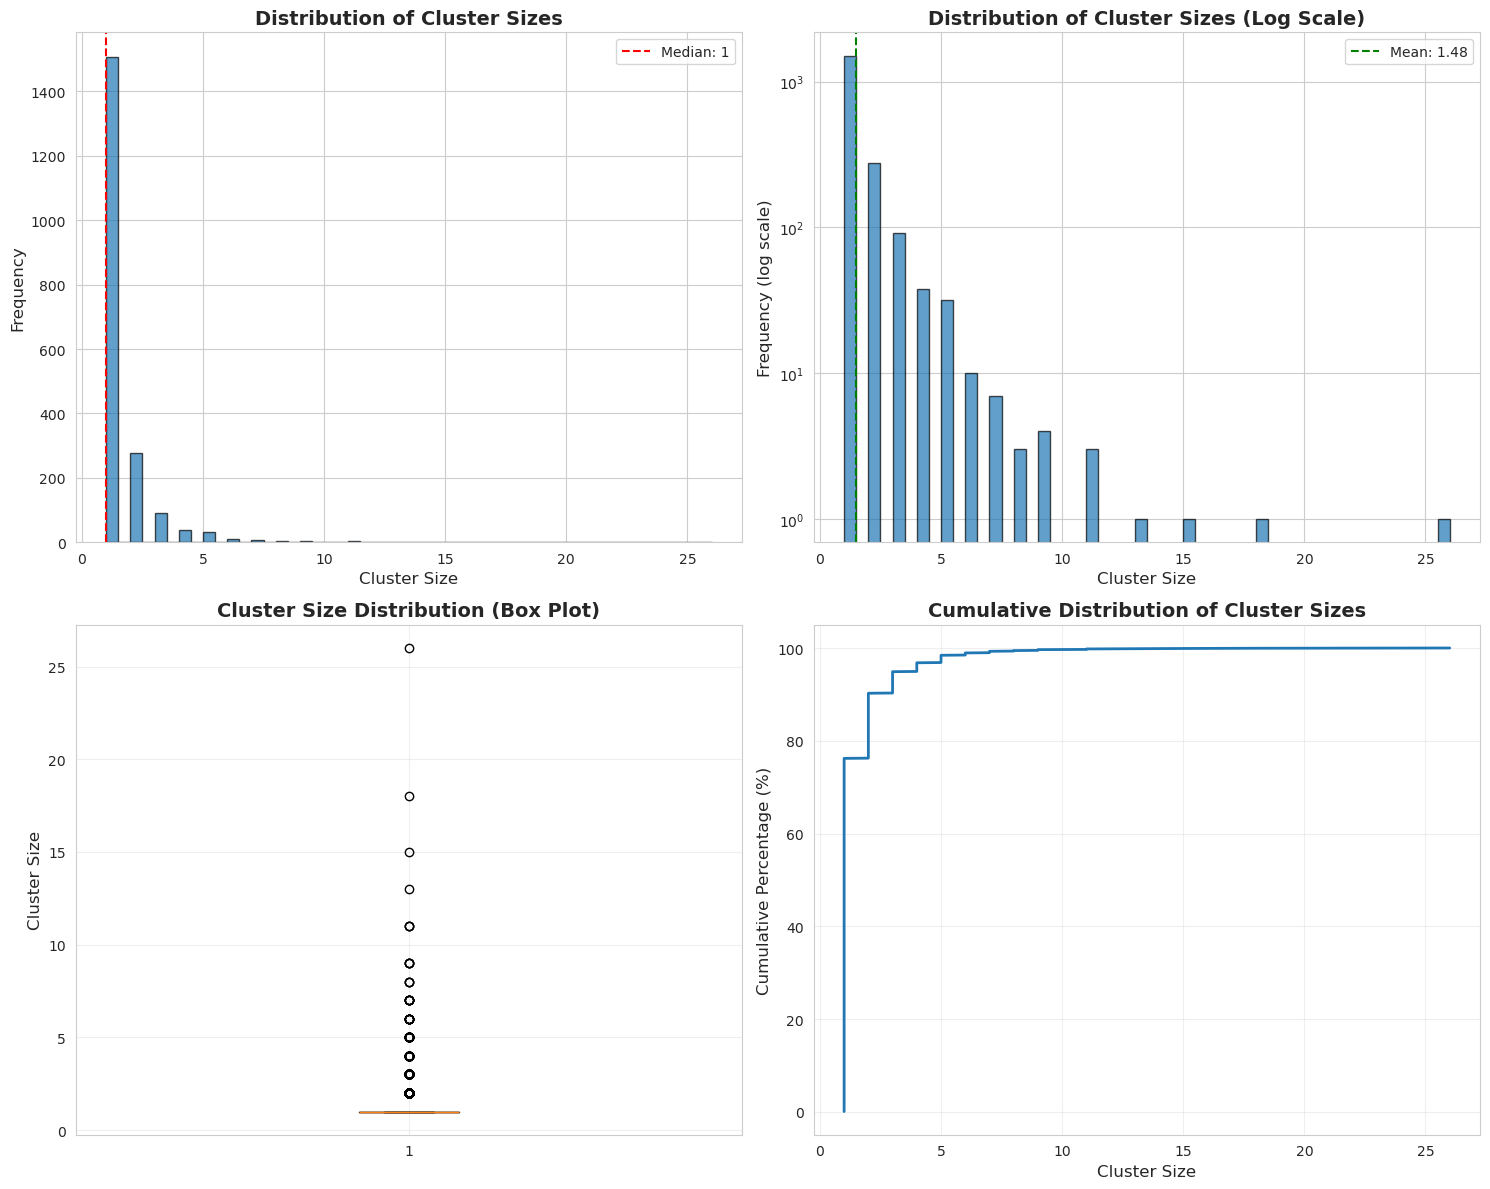

✅ Saved: /scratch/yunmin/data/graph/train/sequence_length_distribution.png


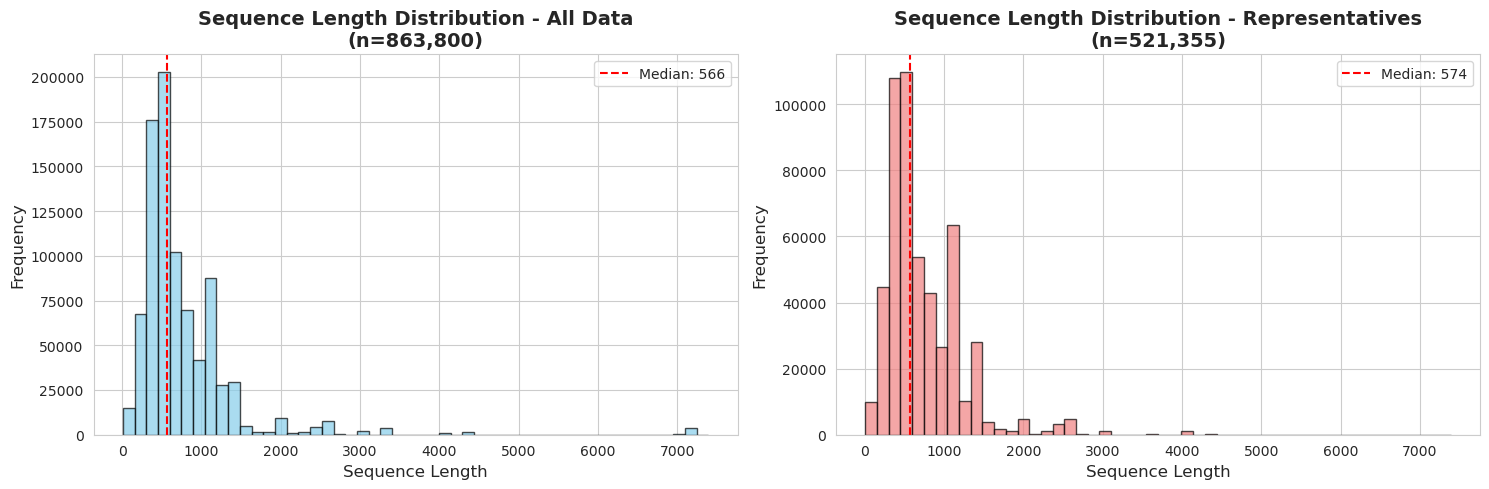

✅ Saved: /scratch/yunmin/data/graph/train/binding_affinity_distribution.png


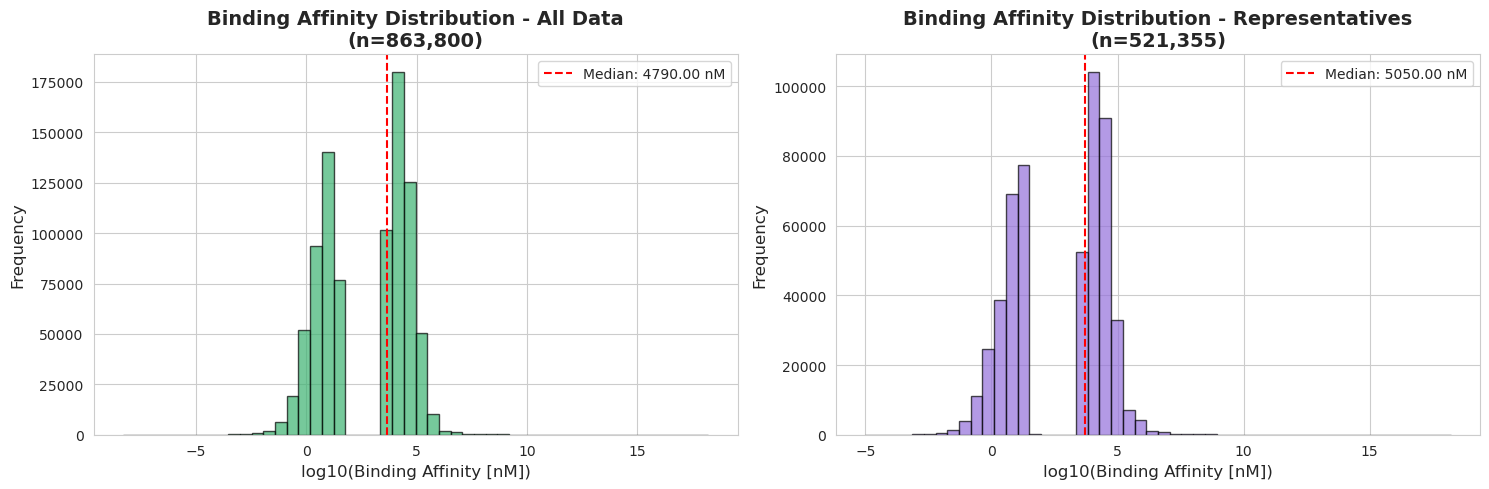

✅ Saved: /scratch/yunmin/data/graph/train/data_source_composition.png


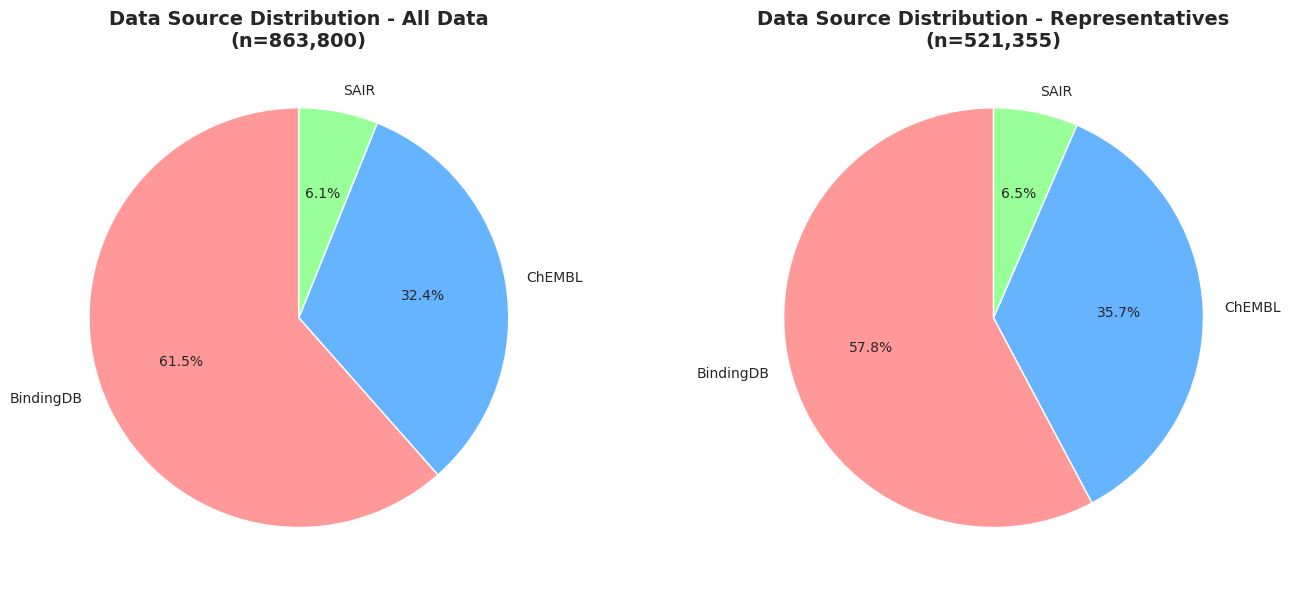

✅ Saved: /scratch/yunmin/data/graph/train/target_type_distribution.png


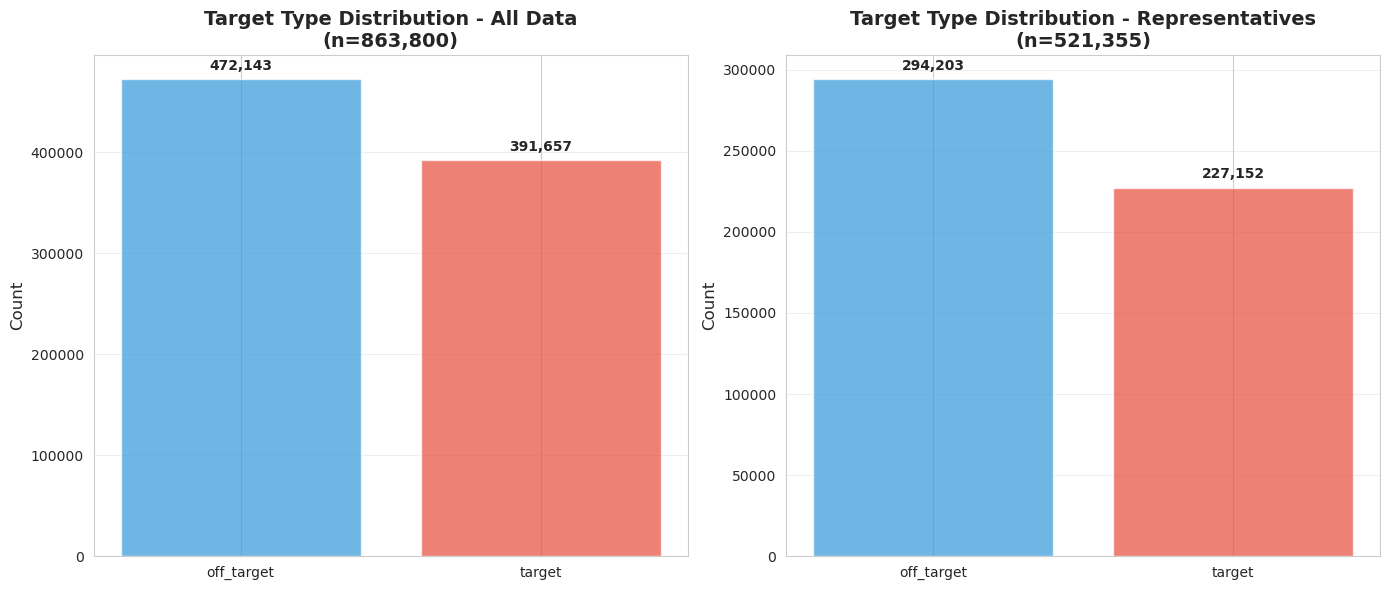

✅ Saved: /scratch/yunmin/data/graph/train/clustering_summary.png


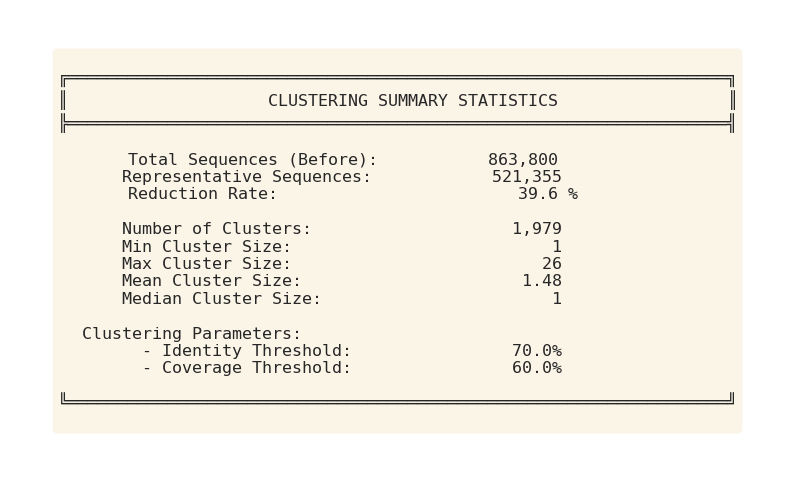


All visualizations complete!


In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("\n" + "=" * 80)
print("STEP 10: Visualizing clustering results")
print("=" * 80)

# 1. Cluster Size Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of cluster sizes
axes[0, 0].hist(cluster_sizes, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Cluster Size', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
axes[0, 0].axvline(np.median(cluster_sizes), color='red', linestyle='--', 
                   label=f'Median: {np.median(cluster_sizes):.0f}')
axes[0, 0].legend()

# Log-scale histogram for better visualization
axes[0, 1].hist(cluster_sizes, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Cluster Size', fontsize=12)
axes[0, 1].set_ylabel('Frequency (log scale)', fontsize=12)
axes[0, 1].set_title('Distribution of Cluster Sizes (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].axvline(np.mean(cluster_sizes), color='green', linestyle='--', 
                   label=f'Mean: {np.mean(cluster_sizes):.2f}')
axes[0, 1].legend()

# Box plot of cluster sizes
axes[1, 0].boxplot(cluster_sizes, vert=True)
axes[1, 0].set_ylabel('Cluster Size', fontsize=12)
axes[1, 0].set_title('Cluster Size Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_sizes = np.sort(cluster_sizes)
cumulative = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes) * 100
axes[1, 1].plot(sorted_sizes, cumulative, linewidth=2)
axes[1, 1].set_xlabel('Cluster Size', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_size_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_size_distribution.png")
plt.show()

# 2. Sequence Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before clustering
axes[0].hist(total_df_dedup['sequence_length'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Sequence Length Distribution - All Data\n(n={len(total_df_dedup):,})', 
                  fontsize=14, fontweight='bold')
axes[0].axvline(total_df_dedup['sequence_length'].median(), color='red', linestyle='--', 
               label=f"Median: {total_df_dedup['sequence_length'].median():.0f}")
axes[0].legend()

# After clustering (representatives)
axes[1].hist(representative_df['sequence_length'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Sequence Length Distribution - Representatives\n(n={len(representative_df):,})', 
                  fontsize=14, fontweight='bold')
axes[1].axvline(representative_df['sequence_length'].median(), color='red', linestyle='--', 
               label=f"Median: {representative_df['sequence_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/sequence_length_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/sequence_length_distribution.png")
plt.show()

# 3. Binding Affinity Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before clustering (log scale)
valid_assay_all = total_df_dedup[total_df_dedup['representative_assay_nM'].notna()]['representative_assay_nM']
axes[0].hist(np.log10(valid_assay_all), bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0].set_xlabel('log10(Binding Affinity [nM])', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Binding Affinity Distribution - All Data\n(n={len(valid_assay_all):,})', 
                  fontsize=14, fontweight='bold')
axes[0].axvline(np.log10(valid_assay_all.median()), color='red', linestyle='--', 
               label=f"Median: {valid_assay_all.median():.2f} nM")
axes[0].legend()

# After clustering (representatives)
valid_assay_rep = representative_df[representative_df['representative_assay_nM'].notna()]['representative_assay_nM']
axes[1].hist(np.log10(valid_assay_rep), bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].set_xlabel('log10(Binding Affinity [nM])', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Binding Affinity Distribution - Representatives\n(n={len(valid_assay_rep):,})', 
                  fontsize=14, fontweight='bold')
axes[1].axvline(np.log10(valid_assay_rep.median()), color='red', linestyle='--', 
               label=f"Median: {valid_assay_rep.median():.2f} nM")
axes[1].legend()

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/binding_affinity_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/binding_affinity_distribution.png")
plt.show()

# 4. Data Source Composition
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before clustering
source_counts_all = total_df_dedup['data_source'].value_counts()
axes[0].pie(source_counts_all, labels=source_counts_all.index, autopct='%1.1f%%', 
           startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title(f'Data Source Distribution - All Data\n(n={len(total_df_dedup):,})', 
                 fontsize=14, fontweight='bold')

# After clustering
source_counts_rep = representative_df['data_source'].value_counts()
axes[1].pie(source_counts_rep, labels=source_counts_rep.index, autopct='%1.1f%%', 
           startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title(f'Data Source Distribution - Representatives\n(n={len(representative_df):,})', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/data_source_composition.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/data_source_composition.png")
plt.show()

# 5. Target Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before clustering
target_counts_all = total_df_dedup['target_type'].value_counts()
axes[0].bar(target_counts_all.index, target_counts_all.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Target Type Distribution - All Data\n(n={len(total_df_dedup):,})', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(target_counts_all.values):
    axes[0].text(i, v + max(target_counts_all.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

# After clustering
target_counts_rep = representative_df['target_type'].value_counts()
axes[1].bar(target_counts_rep.index, target_counts_rep.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Target Type Distribution - Representatives\n(n={len(representative_df):,})', 
                 fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(target_counts_rep.values):
    axes[1].text(i, v + max(target_counts_rep.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/target_type_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/target_type_distribution.png")
plt.show()

# 6. Summary Statistics
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

summary_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    CLUSTERING SUMMARY STATISTICS                 ║
╠══════════════════════════════════════════════════════════════════╣
                                                                   
  Total Sequences (Before):        {len(total_df_dedup):>10,}             
  Representative Sequences:         {len(representative_df):>10,}             
  Reduction Rate:                   {(1 - len(representative_df)/len(total_df_dedup))*100:>9.1f} %           
                                                                   
  Number of Clusters:               {len(clusters):>10,}             
  Min Cluster Size:                 {min(cluster_sizes):>10}             
  Max Cluster Size:                 {max(cluster_sizes):>10}             
  Mean Cluster Size:                {np.mean(cluster_sizes):>10.2f}             
  Median Cluster Size:              {np.median(cluster_sizes):>10.0f}             
                                                                   
  Clustering Parameters:                                           
    - Identity Threshold:           {min_seq_id:>10.1%}             
    - Coverage Threshold:           {coverage:>10.1%}             
                                                                   
╚══════════════════════════════════════════════════════════════════╝
"""

ax.text(0.5, 0.5, summary_text, fontsize=12, family='monospace',
        ha='center', va='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('/scratch/yunmin/data/graph/train/clustering_summary.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/clustering_summary.png")
plt.show()

print("\n" + "=" * 80)
print("All visualizations complete!")
print("=" * 80)

## Train/Test set splitting

In [105]:
# ========================================================================
# STEP 10: Train/Val/Test Splitting by Clusters
# ========================================================================

from sklearn.model_selection import train_test_split

print("\n" + "=" * 80)
print("STEP 10: Splitting clusters into Train/Val/Test sets")
print("=" * 80)

# Configuration
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

print(f"\nSplit ratios:")
print(f"  - Train: {TRAIN_RATIO:.0%}")
print(f"  - Val:   {VAL_RATIO:.0%}")
print(f"  - Test:  {TEST_RATIO:.0%}")

# Get all cluster IDs
all_cluster_ids = np.array(list(clusters.keys()))
print(f"\nTotal clusters: {len(all_cluster_ids):,}")

# First split: Train vs (Val + Test)
train_clusters, temp_clusters = train_test_split(
    all_cluster_ids,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

# Second split: Val vs Test
val_clusters, test_clusters = train_test_split(
    temp_clusters,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

print(f"\n📊 Cluster distribution:")
print(f"  - Train clusters: {len(train_clusters):,} ({len(train_clusters)/len(all_cluster_ids)*100:.1f}%)")
print(f"  - Val clusters:   {len(val_clusters):,} ({len(val_clusters)/len(all_cluster_ids)*100:.1f}%)")
print(f"  - Test clusters:  {len(test_clusters):,} ({len(test_clusters)/len(all_cluster_ids)*100:.1f}%)")

# Verify no overlap
assert len(set(train_clusters) & set(val_clusters)) == 0, "Train/Val overlap detected!"
assert len(set(train_clusters) & set(test_clusters)) == 0, "Train/Test overlap detected!"
assert len(set(val_clusters) & set(test_clusters)) == 0, "Val/Test overlap detected!"
print(f"✅ No cluster overlap between splits")


STEP 10: Splitting clusters into Train/Val/Test sets

Split ratios:
  - Train: 70%
  - Val:   15%
  - Test:  15%

Total clusters: 1,979

📊 Cluster distribution:
  - Train clusters: 1,385 (70.0%)
  - Val clusters:   297 (15.0%)
  - Test clusters:  297 (15.0%)
✅ No cluster overlap between splits


In [106]:
# ========================================================================
# STEP 11: Create train/val/test dataframes
# ========================================================================

print("\n" + "=" * 80)
print("STEP 11: Creating train/val/test datasets")
print("=" * 80)

# Split the representative dataset (already clustered)
train_df = representative_df[representative_df['cluster_id'].isin(train_clusters)].copy()
val_df = representative_df[representative_df['cluster_id'].isin(val_clusters)].copy()
test_df = representative_df[representative_df['cluster_id'].isin(test_clusters)].copy()

# Add split column
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print(f"\n📊 Protein-ligand pairs distribution:")
print(f"  - Train: {len(train_df):,} ({len(train_df)/len(representative_df)*100:.1f}%)")
print(f"  - Val:   {len(val_df):,} ({len(val_df)/len(representative_df)*100:.1f}%)")
print(f"  - Test:  {len(test_df):,} ({len(test_df)/len(representative_df)*100:.1f}%)")

# Check unique proteins
train_proteins = train_df[['uniprot_id', 'sequence']].drop_duplicates()
val_proteins = val_df[['uniprot_id', 'sequence']].drop_duplicates()
test_proteins = test_df[['uniprot_id', 'sequence']].drop_duplicates()

print(f"\n📊 Unique proteins distribution:")
print(f"  - Train: {len(train_proteins):,} ({len(train_proteins)/len(representative_proteins)*100:.1f}%)")
print(f"  - Val:   {len(val_proteins):,} ({len(val_proteins)/len(representative_proteins)*100:.1f}%)")
print(f"  - Test:  {len(test_proteins):,} ({len(test_proteins)/len(representative_proteins)*100:.1f}%)")

# Check ligands per protein
print(f"\n📊 Ligands per protein:")
print(f"  - Train: {len(train_df) / len(train_proteins):.2f}")
print(f"  - Val:   {len(val_df) / len(val_proteins):.2f}")
print(f"  - Test:  {len(test_df) / len(test_proteins):.2f}")



STEP 11: Creating train/val/test datasets

📊 Protein-ligand pairs distribution:
  - Train: 345,995 (66.4%)
  - Val:   78,006 (15.0%)
  - Test:  97,354 (18.7%)

📊 Unique proteins distribution:
  - Train: 1,385 (70.0%)
  - Val:   297 (15.0%)
  - Test:  297 (15.0%)

📊 Ligands per protein:
  - Train: 249.82
  - Val:   262.65
  - Test:  327.79


In [107]:
# ========================================================================
# STEP 12: Check data distribution quality
# ========================================================================

print("\n" + "=" * 80)
print("STEP 12: Verifying split quality")
print("=" * 80)

# Check target/off-target distribution
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n_target = (split_df['target_type'] == 'target').sum()
    n_off = (split_df['target_type'] == 'off_target').sum()
    total = n_target + n_off
    print(f"\n{split_name} target distribution:")
    print(f"  - Targets:     {n_target:,} ({n_target/total*100:.1f}%)")
    print(f"  - Off-targets: {n_off:,} ({n_off/total*100:.1f}%)")

# Check data source distribution
print(f"\n📊 Data source distribution:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    source_counts = split_df['data_source'].value_counts()
    print(f"\n{split_name}:")
    for source, count in source_counts.items():
        print(f"  - {source}: {count:,} ({count/len(split_df)*100:.1f}%)")

# Check binding affinity distribution
print(f"\n📊 Binding affinity (median nM):")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    valid_assay = split_df[split_df['representative_assay_nM'].notna()]['representative_assay_nM']
    if len(valid_assay) > 0:
        print(f"  - {split_name}: {valid_assay.median():.2f} nM (n={len(valid_assay):,})")



STEP 12: Verifying split quality

Train target distribution:
  - Targets:     153,324 (44.3%)
  - Off-targets: 192,671 (55.7%)

Val target distribution:
  - Targets:     37,882 (48.6%)
  - Off-targets: 40,124 (51.4%)

Test target distribution:
  - Targets:     35,946 (36.9%)
  - Off-targets: 61,408 (63.1%)

📊 Data source distribution:

Train:
  - BindingDB: 195,296 (56.4%)
  - ChEMBL: 127,814 (36.9%)
  - SAIR: 22,885 (6.6%)

Val:
  - BindingDB: 42,864 (54.9%)
  - ChEMBL: 29,434 (37.7%)
  - SAIR: 5,708 (7.3%)

Test:
  - BindingDB: 63,090 (64.8%)
  - ChEMBL: 28,949 (29.7%)
  - SAIR: 5,315 (5.5%)

📊 Binding affinity (median nM):
  - Train: 5000.00 nM (n=345,995)
  - Val: 3652.00 nM (n=78,006)
  - Test: 7900.00 nM (n=97,354)


In [108]:
# ========================================================================
# STEP 13: Save split datasets
# ========================================================================

print("\n" + "=" * 80)
print("STEP 13: Saving train/val/test datasets")
print("=" * 80)

output_dir = "/scratch/yunmin/data/graph/train"

# Save individual splits
train_df.to_csv(f"{output_dir}/train_set.csv", index=False)
val_df.to_csv(f"{output_dir}/val_set.csv", index=False)
test_df.to_csv(f"{output_dir}/test_set.csv", index=False)

print(f"✅ Saved: {output_dir}/train_set.csv ({len(train_df):,} rows)")
print(f"✅ Saved: {output_dir}/val_set.csv ({len(val_df):,} rows)")
print(f"✅ Saved: {output_dir}/test_set.csv ({len(test_df):,} rows)")

# Save combined dataset with split labels
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
combined_df.to_csv(f"{output_dir}/all_splits_labeled.csv", index=False)
print(f"✅ Saved: {output_dir}/all_splits_labeled.csv ({len(combined_df):,} rows)")

# Save cluster split assignments
cluster_splits = pd.DataFrame({
    'cluster_id': list(train_clusters) + list(val_clusters) + list(test_clusters),
    'split': ['train'] * len(train_clusters) + ['val'] * len(val_clusters) + ['test'] * len(test_clusters)
})
cluster_splits.to_csv(f"{output_dir}/cluster_splits.csv", index=False)
print(f"✅ Saved: {output_dir}/cluster_splits.csv ({len(cluster_splits):,} clusters)")

print("\n" + "=" * 80)
print("Train/Val/Test splitting complete!")
print("=" * 80)


STEP 13: Saving train/val/test datasets
✅ Saved: /scratch/yunmin/data/graph/train/train_set.csv (345,995 rows)
✅ Saved: /scratch/yunmin/data/graph/train/val_set.csv (78,006 rows)
✅ Saved: /scratch/yunmin/data/graph/train/test_set.csv (97,354 rows)
✅ Saved: /scratch/yunmin/data/graph/train/all_splits_labeled.csv (521,355 rows)
✅ Saved: /scratch/yunmin/data/graph/train/cluster_splits.csv (1,979 clusters)

Train/Val/Test splitting complete!


In [109]:
# ========================================================================
# STEP 14: Final summary statistics
# ========================================================================

print("\n" + "=" * 80)
print("FINAL DATASET SUMMARY")
print("=" * 80)

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    DATASET SPLIT SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣

  TRAIN SET:
    Protein-ligand pairs:       {len(train_df):>10,}
    Unique proteins:            {len(train_proteins):>10,}
    Unique ligands:             {train_df['ligand_smiles'].nunique():>10,}
    Clusters:                   {len(train_clusters):>10,}
    
  VALIDATION SET:
    Protein-ligand pairs:       {len(val_df):>10,}
    Unique proteins:            {len(val_proteins):>10,}
    Unique ligands:             {val_df['ligand_smiles'].nunique():>10,}
    Clusters:                   {len(val_clusters):>10,}
    
  TEST SET:
    Protein-ligand pairs:       {len(test_df):>10,}
    Unique proteins:            {len(test_proteins):>10,}
    Unique ligands:             {test_df['ligand_smiles'].nunique():>10,}
    Clusters:                   {len(test_clusters):>10,}
    
  TOTAL:
    Protein-ligand pairs:       {len(combined_df):>10,}
    Unique proteins:            {len(representative_proteins):>10,}
    Clusters:                   {len(all_cluster_ids):>10,}
    
╚══════════════════════════════════════════════════════════════════╝
"""

print(summary)


FINAL DATASET SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║                    DATASET SPLIT SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣

  TRAIN SET:
    Protein-ligand pairs:          345,995
    Unique proteins:                 1,385
    Unique ligands:                273,644
    Clusters:                        1,385

  VALIDATION SET:
    Protein-ligand pairs:           78,006
    Unique proteins:                   297
    Unique ligands:                 68,460
    Clusters:                          297

  TEST SET:
    Protein-ligand pairs:           97,354
    Unique proteins:                   297
    Unique ligands:                 85,180
    Clusters:                          297

  TOTAL:
    Protein-ligand pairs:          521,355
    Unique proteins:                 1,979
    Clusters:                        1,979

╚══════════════════════════════════════════════════════════════════


STEP 15: Creating comprehensive split distribution plots

1️⃣ Creating target type distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/split_target_type_distribution.png


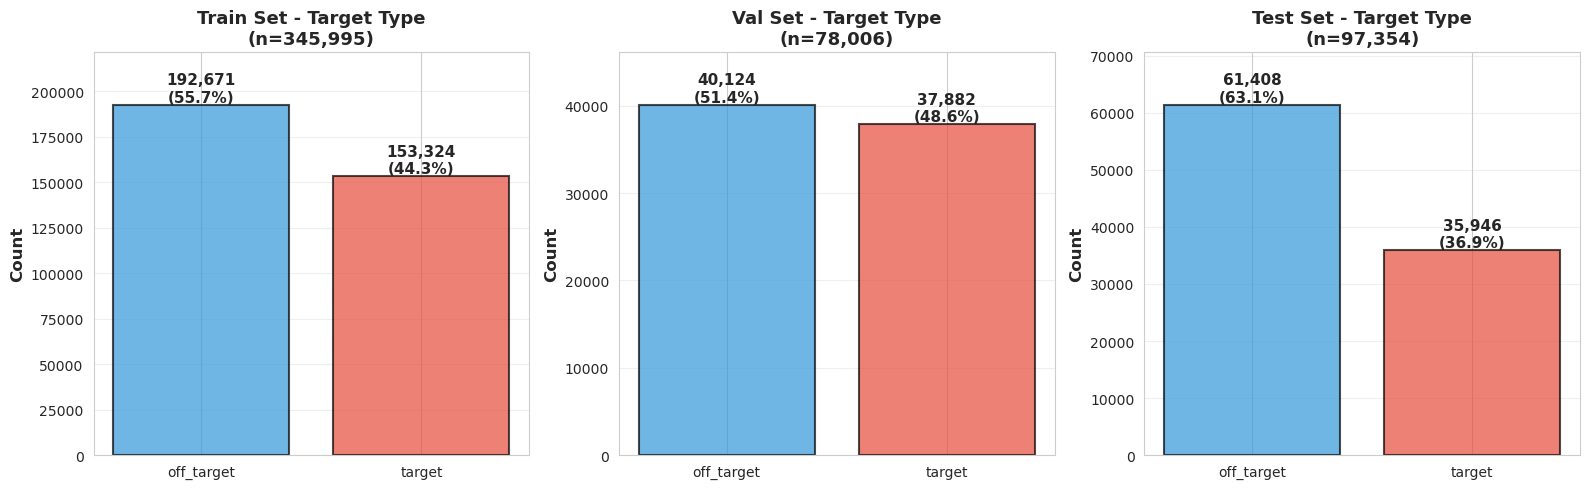


2️⃣ Creating stacked target type comparison...
✅ Saved: /scratch/yunmin/data/graph/train/split_target_type_stacked.png


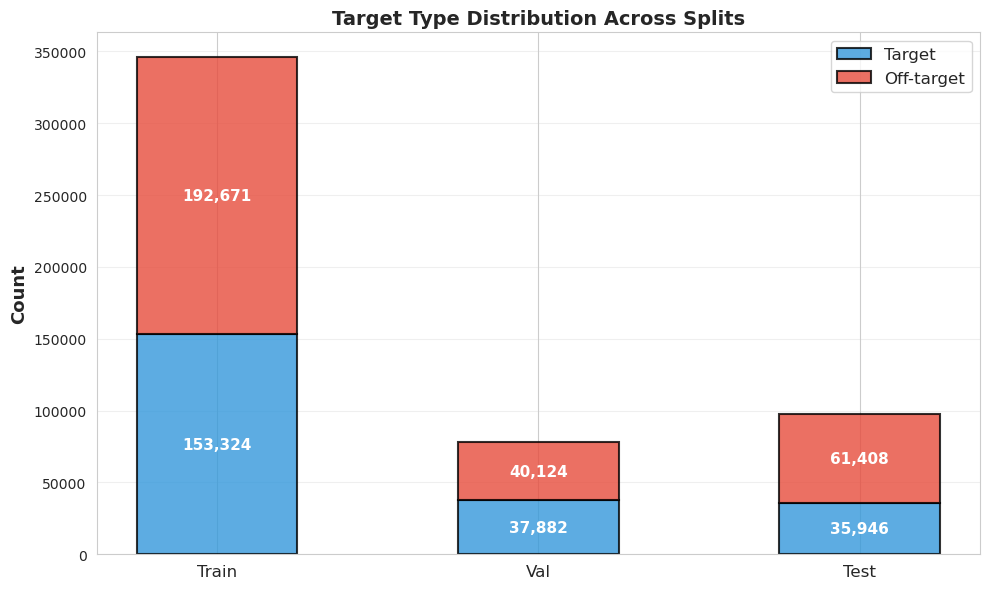


3️⃣ Creating data source distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/split_data_source_distribution.png


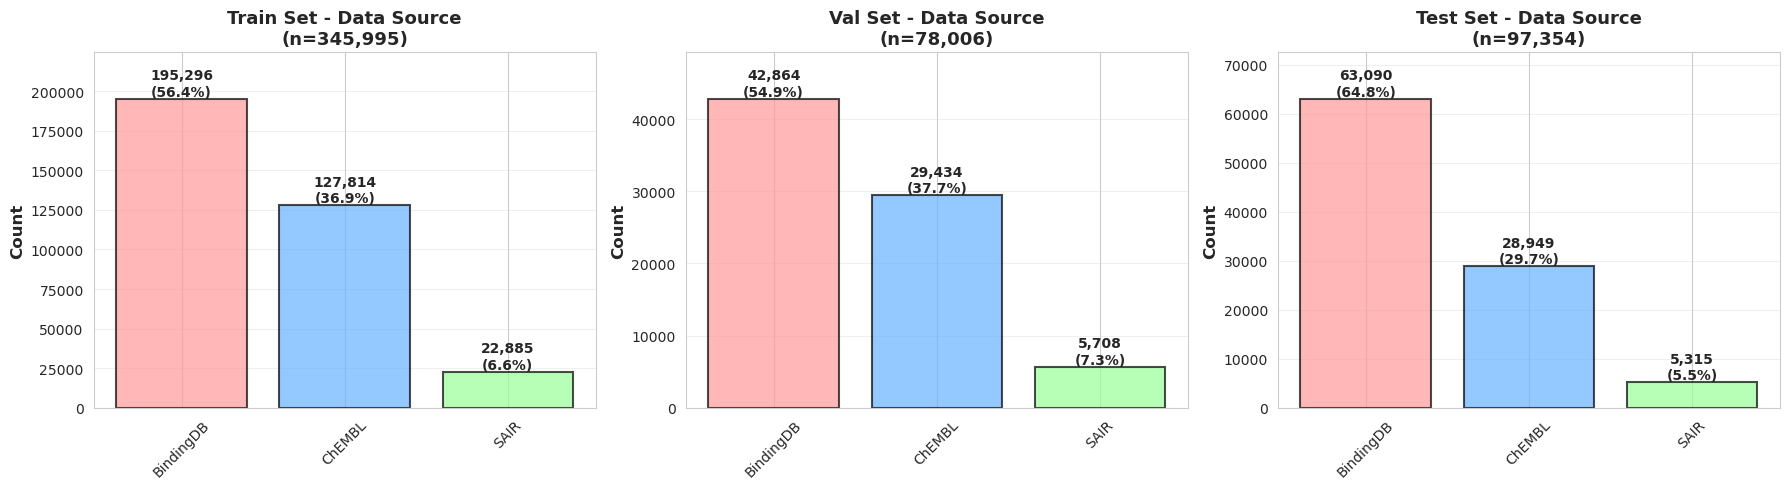


4️⃣ Creating stacked data source comparison...
✅ Saved: /scratch/yunmin/data/graph/train/split_data_source_stacked.png


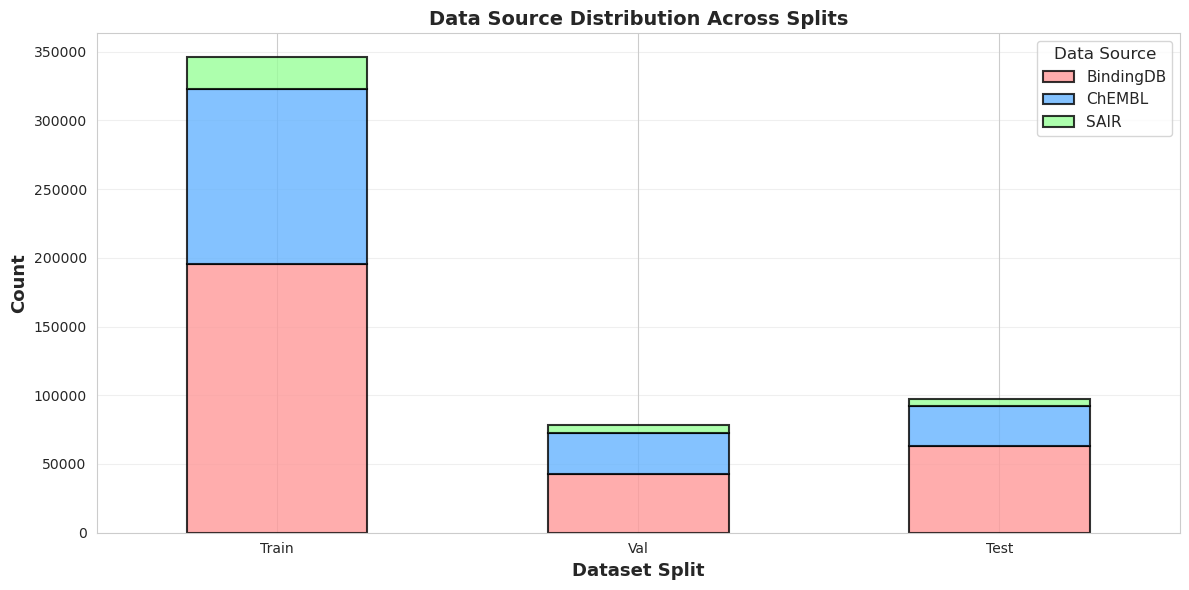


5️⃣ Creating protein-ligand pairs distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/split_pl_pairs_distribution.png


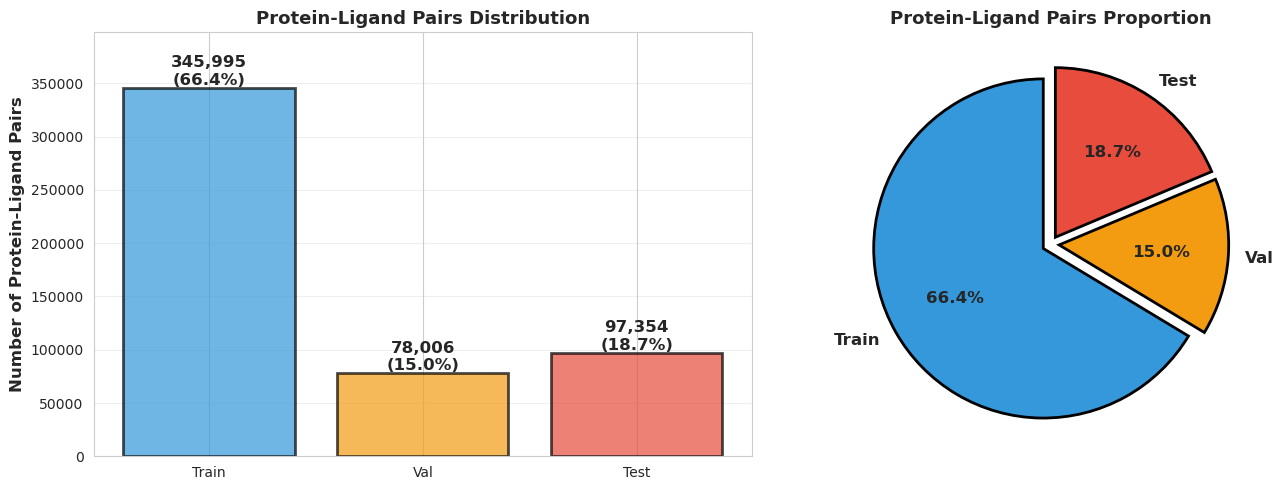


6️⃣ Creating unique proteins distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/split_unique_proteins_distribution.png


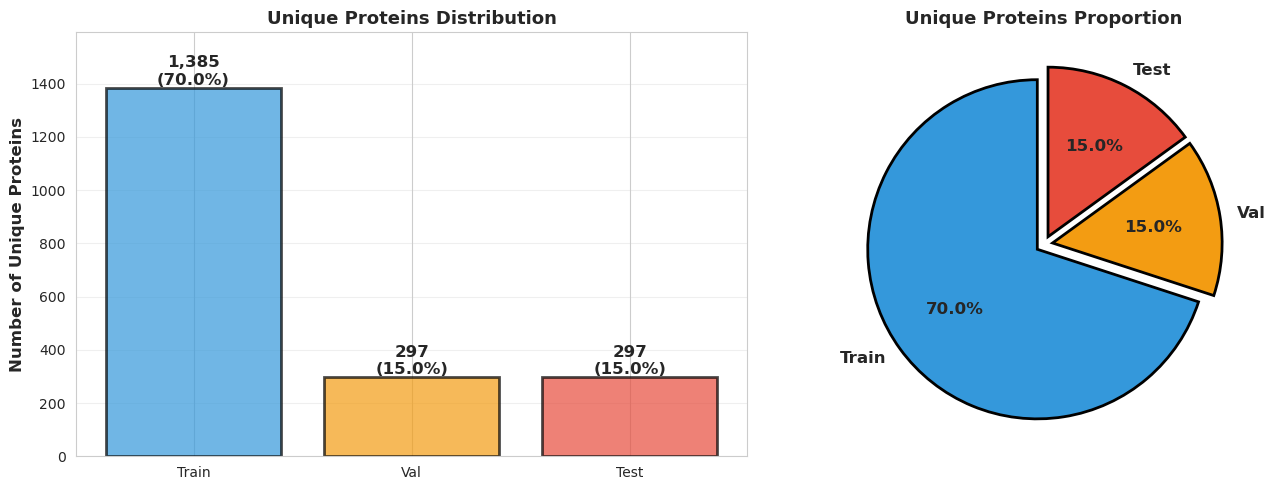


7️⃣ Creating unique ligands distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/split_unique_ligands_distribution.png


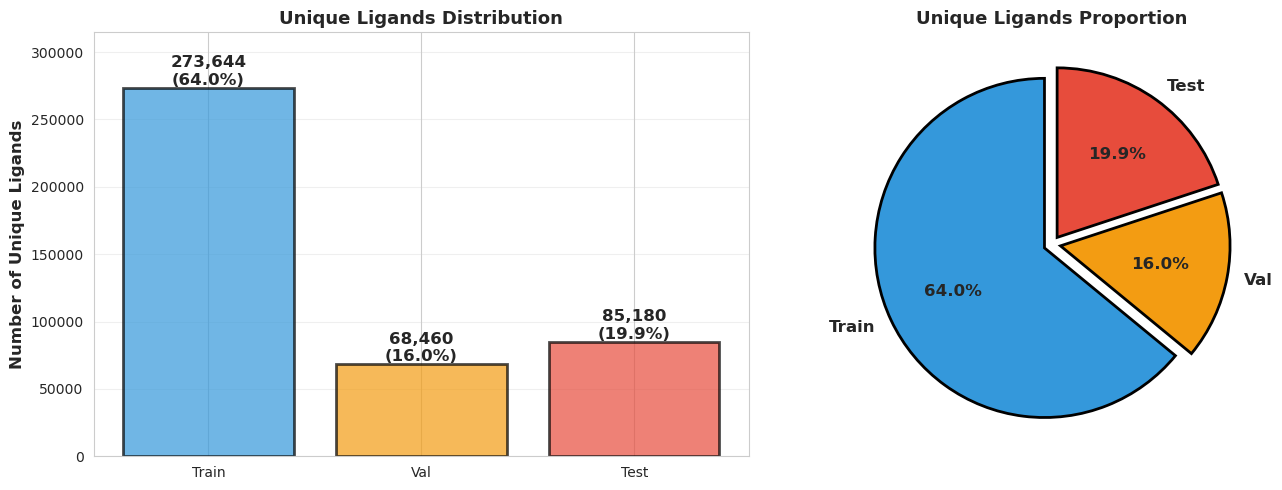


8️⃣ Creating comprehensive summary comparison...
✅ Saved: /scratch/yunmin/data/graph/train/split_comprehensive_summary.png


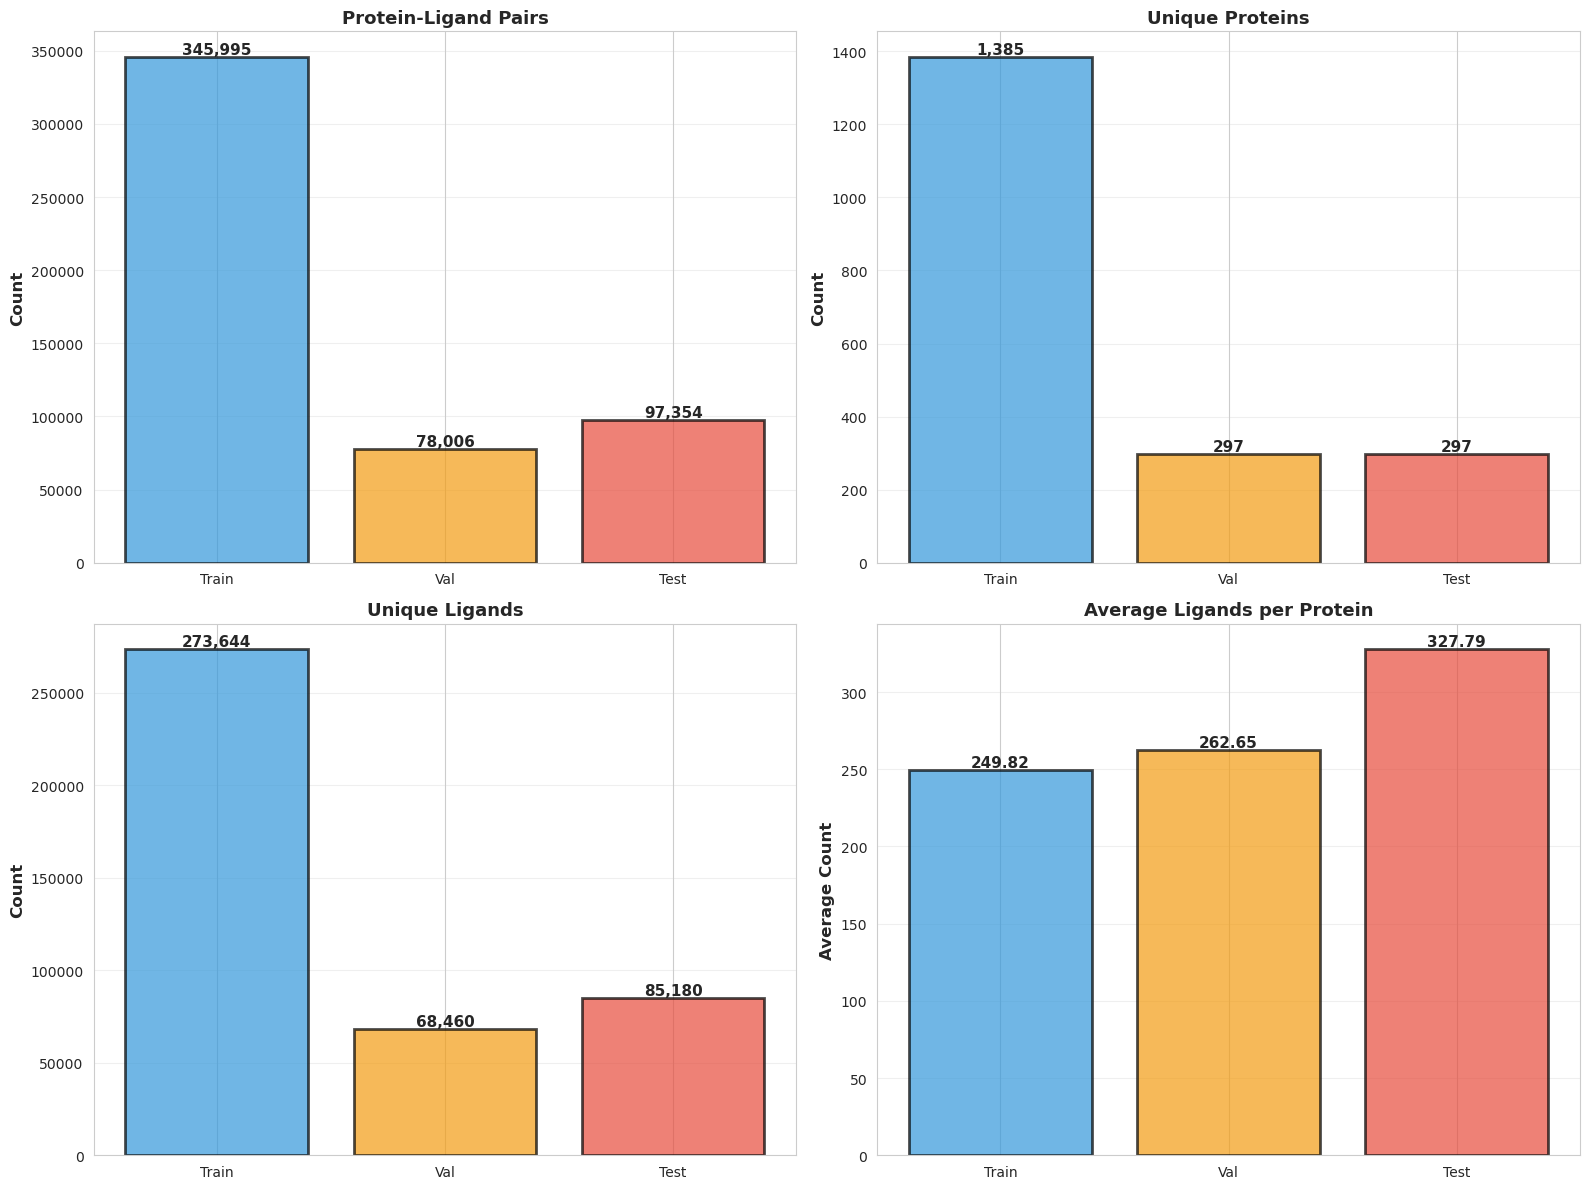


9️⃣ Creating summary statistics table...
✅ Saved: /scratch/yunmin/data/graph/train/split_summary_table.png


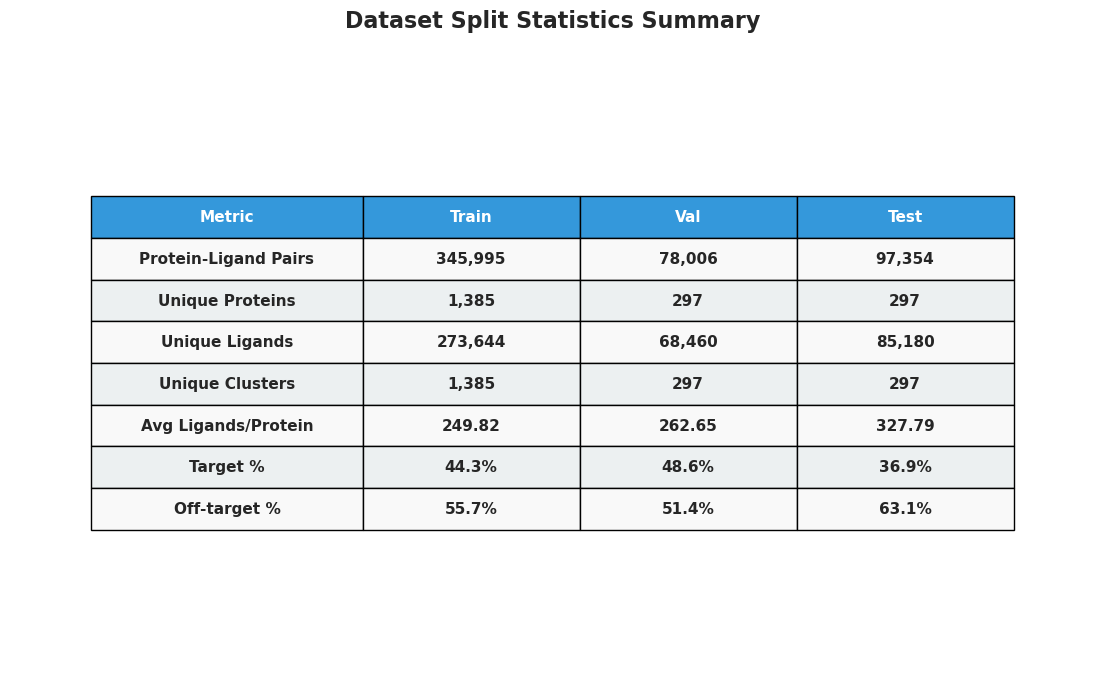


SUMMARY STATISTICS
              Metric   Train    Val   Test
Protein-Ligand Pairs 345,995 78,006 97,354
     Unique Proteins   1,385    297    297
      Unique Ligands 273,644 68,460 85,180
     Unique Clusters   1,385    297    297
 Avg Ligands/Protein  249.82 262.65 327.79
            Target %   44.3%  48.6%  36.9%
        Off-target %   55.7%  51.4%  63.1%

All split distribution visualizations complete!
✅ Generated 9 visualization files:
   1. split_target_type_distribution.png - Individual target type bar charts
   2. split_target_type_stacked.png - Stacked target type comparison
   3. split_data_source_distribution.png - Individual data source bar charts
   4. split_data_source_stacked.png - Stacked data source comparison
   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)
   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)
   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)
   8. split_comprehensive_summary.png -

In [114]:
# ========================================================================
# STEP 15: Comprehensive Split Distribution Visualizations
# ========================================================================

print("\n" + "=" * 80)
print("STEP 15: Creating comprehensive split distribution plots")
print("=" * 80)

# ========================================================================
# 1. Target Type Distribution across splits
# ========================================================================

print("\n1️⃣ Creating target type distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    target_counts = split_df['target_type'].value_counts()
    colors = ['#3498db', '#e74c3c']
    
    bars = axes[idx].bar(target_counts.index, target_counts.values, 
                         color=colors[:len(target_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Target Type\n(n={len(split_df):,})', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    axes[idx].set_ylim(0, max(target_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_target_type_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_target_type_distribution.png")
plt.show()

# ========================================================================
# 2. Target Type Distribution - Stacked Comparison
# ========================================================================

print("\n2️⃣ Creating stacked target type comparison...")

split_data = []
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    target_counts = split_df['target_type'].value_counts()
    split_data.append({
        'split': split_name,
        'target': target_counts.get('target', 0),
        'off_target': target_counts.get('off_target', 0)
    })

split_df_vis = pd.DataFrame(split_data)
split_df_vis = split_df_vis.set_index('split')

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(split_df_vis))
width = 0.5

bars1 = ax.bar(x, split_df_vis['target'], width, label='Target', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, split_df_vis['off_target'], width, bottom=split_df_vis['target'],
               label='Off-target', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_title('Target Type Distribution Across Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_df_vis.index, fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_y() + height/2.,
                   f'{int(height):,}',
                   ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_target_type_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_target_type_stacked.png")
plt.show()

# ========================================================================
# 3. Data Source Distribution across splits
# ========================================================================

print("\n3️⃣ Creating data source distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    source_counts = split_df['data_source'].value_counts()
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    bars = axes[idx].bar(source_counts.index, source_counts.values, 
                         color=colors[:len(source_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Data Source\n(n={len(split_df):,})', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[idx].set_ylim(0, max(source_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_data_source_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_data_source_distribution.png")
plt.show()

# ========================================================================
# 4. Data Source Distribution - Stacked Comparison
# ========================================================================

print("\n4️⃣ Creating stacked data source comparison...")

split_source_data = {}
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    source_counts = split_df['data_source'].value_counts()
    split_source_data[split_name] = source_counts

split_source_df = pd.DataFrame(split_source_data).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

split_source_df.T.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#ff9999', '#66b3ff', '#99ff99'],
                       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
ax.set_title('Data Source Distribution Across Splits', fontsize=14, fontweight='bold')
ax.legend(title='Data Source', fontsize=11, title_fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_data_source_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_data_source_stacked.png")
plt.show()

# ========================================================================
# 5. Protein-Ligand Pairs Distribution
# ========================================================================

print("\n5️⃣ Creating protein-ligand pairs distribution plots...")

pairs_data = {
    'Train': len(train_df),
    'Val': len(val_df),
    'Test': len(test_df)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(pairs_data.keys())
counts = list(pairs_data.values())
colors_split = ['#3498db', '#f39c12', '#e74c3c']

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Protein-Ligand Pairs', fontsize=12, fontweight='bold')
axes[0].set_title('Protein-Ligand Pairs Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Protein-Ligand Pairs Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_pl_pairs_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_pl_pairs_distribution.png")
plt.show()

# ========================================================================
# 6. Unique Proteins Distribution
# ========================================================================

print("\n6️⃣ Creating unique proteins distribution plots...")

proteins_data = {
    'Train': len(train_proteins),
    'Val': len(val_proteins),
    'Test': len(test_proteins)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(proteins_data.keys())
counts = list(proteins_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Proteins', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Proteins Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Proteins Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_unique_proteins_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_unique_proteins_distribution.png")
plt.show()

# ========================================================================
# 7. Unique Ligands Distribution
# ========================================================================

print("\n7️⃣ Creating unique ligands distribution plots...")

ligands_data = {
    'Train': train_df['ligand_smiles'].nunique(),
    'Val': val_df['ligand_smiles'].nunique(),
    'Test': test_df['ligand_smiles'].nunique()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(ligands_data.keys())
counts = list(ligands_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Ligands', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Ligands Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Ligands Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_unique_ligands_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_unique_ligands_distribution.png")
plt.show()

# ========================================================================
# 8. Comprehensive Summary Comparison
# ========================================================================

print("\n8️⃣ Creating comprehensive summary comparison...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 8.1 Protein-Ligand Pairs
pairs_data = [len(train_df), len(val_df), len(test_df)]
bars = axes[0, 0].bar(['Train', 'Val', 'Test'], pairs_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Protein-Ligand Pairs', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, pairs_data):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.2 Unique Proteins
proteins_data = [len(train_proteins), len(val_proteins), len(test_proteins)]
bars = axes[0, 1].bar(['Train', 'Val', 'Test'], proteins_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Unique Proteins', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, proteins_data):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.3 Unique Ligands
ligands_data = [train_df['ligand_smiles'].nunique(), 
                val_df['ligand_smiles'].nunique(),
                test_df['ligand_smiles'].nunique()]
bars = axes[1, 0].bar(['Train', 'Val', 'Test'], ligands_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Unique Ligands', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ligands_data):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.4 Ligands per Protein (Average)
avg_ligands = [
    len(train_df) / len(train_proteins),
    len(val_df) / len(val_proteins),
    len(test_df) / len(test_proteins)
]
bars = axes[1, 1].bar(['Train', 'Val', 'Test'], avg_ligands, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Count', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Ligands per Protein', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, avg_ligands):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/split_comprehensive_summary.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_comprehensive_summary.png")
plt.show()

# ========================================================================
# 9. Summary Statistics Table
# ========================================================================

print("\n9️⃣ Creating summary statistics table...")

summary_stats = pd.DataFrame({
    'Metric': [
        'Protein-Ligand Pairs',
        'Unique Proteins',
        'Unique Ligands',
        'Unique Clusters',
        'Avg Ligands/Protein',
        'Target %',
        'Off-target %'
    ],
    'Train': [
        f"{len(train_df):,}",
        f"{len(train_proteins):,}",
        f"{train_df['ligand_smiles'].nunique():,}",
        f"{len(train_clusters):,}",
        f"{len(train_df) / len(train_proteins):.2f}",
        f"{(train_df['target_type'] == 'target').sum() / len(train_df) * 100:.1f}%",
        f"{(train_df['target_type'] == 'off_target').sum() / len(train_df) * 100:.1f}%"
    ],
    'Val': [
        f"{len(val_df):,}",
        f"{len(val_proteins):,}",
        f"{val_df['ligand_smiles'].nunique():,}",
        f"{len(val_clusters):,}",
        f"{len(val_df) / len(val_proteins):.2f}",
        f"{(val_df['target_type'] == 'target').sum() / len(val_df) * 100:.1f}%",
        f"{(val_df['target_type'] == 'off_target').sum() / len(val_df) * 100:.1f}%"
    ],
    'Test': [
        f"{len(test_df):,}",
        f"{len(test_proteins):,}",
        f"{test_df['ligand_smiles'].nunique():,}",
        f"{len(test_clusters):,}",
        f"{len(test_df) / len(test_proteins):.2f}",
        f"{(test_df['target_type'] == 'target').sum() / len(test_df) * 100:.1f}%",
        f"{(test_df['target_type'] == 'off_target').sum() / len(test_df) * 100:.1f}%"
    ]
})

# Create figure with table
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_stats.values, 
                colLabels=summary_stats.columns,
                cellLoc='center', loc='center',
                colWidths=[0.25, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_stats) + 1):
    for j in range(len(summary_stats.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#f9f9f9')
        table[(i, j)].set_text_props(weight='bold')

plt.title('Dataset Split Statistics Summary', fontsize=16, fontweight='bold', pad=20)
plt.savefig('/scratch/yunmin/data/graph/train/split_summary_table.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/split_summary_table.png")
plt.show()

# Print table to console
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_stats.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("All split distribution visualizations complete!")
print("=" * 80)
print(f"✅ Generated 9 visualization files:")
print(f"   1. split_target_type_distribution.png - Individual target type bar charts")
print(f"   2. split_target_type_stacked.png - Stacked target type comparison")
print(f"   3. split_data_source_distribution.png - Individual data source bar charts")
print(f"   4. split_data_source_stacked.png - Stacked data source comparison")
print(f"   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)")
print(f"   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)")
print(f"   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)")
print(f"   8. split_comprehensive_summary.png - 2x2 summary comparison")
print(f"   9. split_summary_table.png - Statistics table")

### Stratified splitting

In [110]:
# ========================================================================
# OPTIONAL: Stratified splitting (if needed)
# ========================================================================

print("\n" + "=" * 80)
print("OPTIONAL: Stratified Splitting by Target Type")
print("=" * 80)
print("(Run this section if you need balanced target/off-target distribution)")

# Get majority target type per cluster
cluster_target_majority = (
    representative_df.groupby('cluster_id')['target_type']
    .agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else 'target')
    .to_dict()
)

# Create stratification labels
cluster_stratify_labels = [cluster_target_majority[cid] for cid in all_cluster_ids]

# Stratified split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=(VAL_RATIO + TEST_RATIO), random_state=RANDOM_SEED)
train_idx, temp_idx = next(splitter.split(all_cluster_ids, cluster_stratify_labels))

train_clusters_strat = all_cluster_ids[train_idx]
temp_clusters_strat = all_cluster_ids[temp_idx]
temp_labels = [cluster_stratify_labels[i] for i in temp_idx]

splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_SEED)
val_idx, test_idx = next(splitter2.split(temp_clusters_strat, temp_labels))

val_clusters_strat = temp_clusters_strat[val_idx]
test_clusters_strat = temp_clusters_strat[test_idx]

print(f"\n📊 Stratified cluster distribution:")
print(f"  - Train: {len(train_clusters_strat):,}")
print(f"  - Val:   {len(val_clusters_strat):,}")
print(f"  - Test:  {len(test_clusters_strat):,}")

# Create stratified splits
train_df_strat = representative_df[representative_df['cluster_id'].isin(train_clusters_strat)].copy()
val_df_strat = representative_df[representative_df['cluster_id'].isin(val_clusters_strat)].copy()
test_df_strat = representative_df[representative_df['cluster_id'].isin(test_clusters_strat)].copy()

# Check target distribution
for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    n_target = (split_df['target_type'] == 'target').sum()
    total = len(split_df)
    print(f"{split_name} target ratio: {n_target/total*100:.1f}%")


OPTIONAL: Stratified Splitting by Target Type
(Run this section if you need balanced target/off-target distribution)

📊 Stratified cluster distribution:
  - Train: 1,385
  - Val:   297
  - Test:  297
Train target ratio: 43.1%
Val target ratio: 46.5%
Test target ratio: 42.4%


In [111]:
# ========================================================================
# OPTIONAL: Save split datasets (Stratified split)
# ========================================================================

print("\n" + "=" * 80)
print("OPTIONAL: Saving train/val/test datasets (Stratified split)")
print("=" * 80)

output_dir = "/scratch/yunmin/data/graph/train"

# Save individual splits
train_df_strat.to_csv(f"{output_dir}/train_set_stratified.csv", index=False)
val_df_strat.to_csv(f"{output_dir}/val_set_stratified.csv", index=False)
test_df_strat.to_csv(f"{output_dir}/test_set_stratified.csv", index=False)

print(f"✅ Saved: {output_dir}/train_set_stratified.csv ({len(train_df_strat):,} rows)")
print(f"✅ Saved: {output_dir}/val_set_stratified.csv ({len(val_df_strat):,} rows)")
print(f"✅ Saved: {output_dir}/test_set_stratified.csv ({len(test_df_strat):,} rows)")

# Save combined dataset with split labels
combined_df = pd.concat([train_df_strat, val_df_strat, test_df_strat], ignore_index=True)
combined_df.to_csv(f"{output_dir}/all_splits_labeled_stratified.csv", index=False)
print(f"✅ Saved: {output_dir}/all_splits_labeled_stratified.csv ({len(combined_df):,} rows)")

# Save cluster split assignments
cluster_splits = pd.DataFrame({
    'cluster_id': list(train_clusters_strat) + list(val_clusters_strat) + list(test_clusters_strat),
    'split': ['train'] * len(train_clusters_strat) + ['val'] * len(val_clusters_strat) + ['test'] * len(test_clusters_strat)
})
cluster_splits.to_csv(f"{output_dir}/cluster_splits_stratified.csv", index=False)
print(f"✅ Saved: {output_dir}/cluster_splits_stratified.csv ({len(cluster_splits):,} clusters)")

print("\n" + "=" * 80)
print("Train/Val/Test splitting complete!")
print("=" * 80)


OPTIONAL: Saving train/val/test datasets (Stratified split)
✅ Saved: /scratch/yunmin/data/graph/train/train_set_stratified.csv (374,020 rows)
✅ Saved: /scratch/yunmin/data/graph/train/val_set_stratified.csv (82,022 rows)
✅ Saved: /scratch/yunmin/data/graph/train/test_set_stratified.csv (65,313 rows)
✅ Saved: /scratch/yunmin/data/graph/train/all_splits_labeled_stratified.csv (521,355 rows)
✅ Saved: /scratch/yunmin/data/graph/train/cluster_splits_stratified.csv (1,979 clusters)

Train/Val/Test splitting complete!



OPTIONAL: Creating comprehensive split distribution plots (stratified splitting)

1️⃣ Creating target type distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_target_type_distribution.png


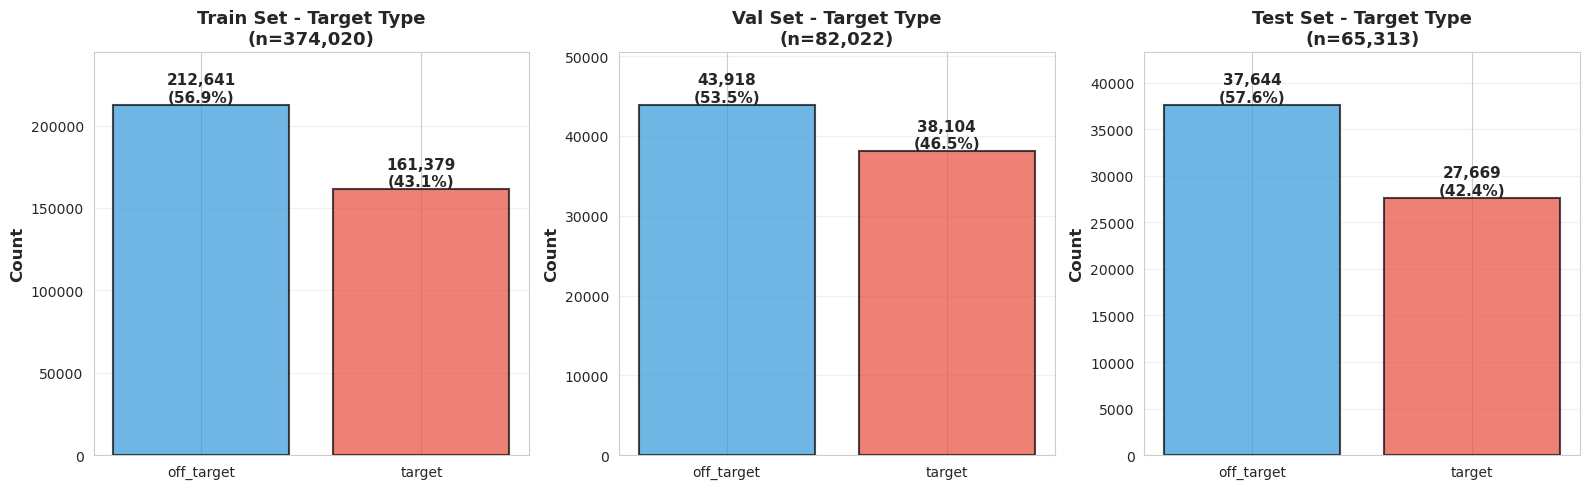


2️⃣ Creating stacked target type comparison...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_target_type_stacked.png


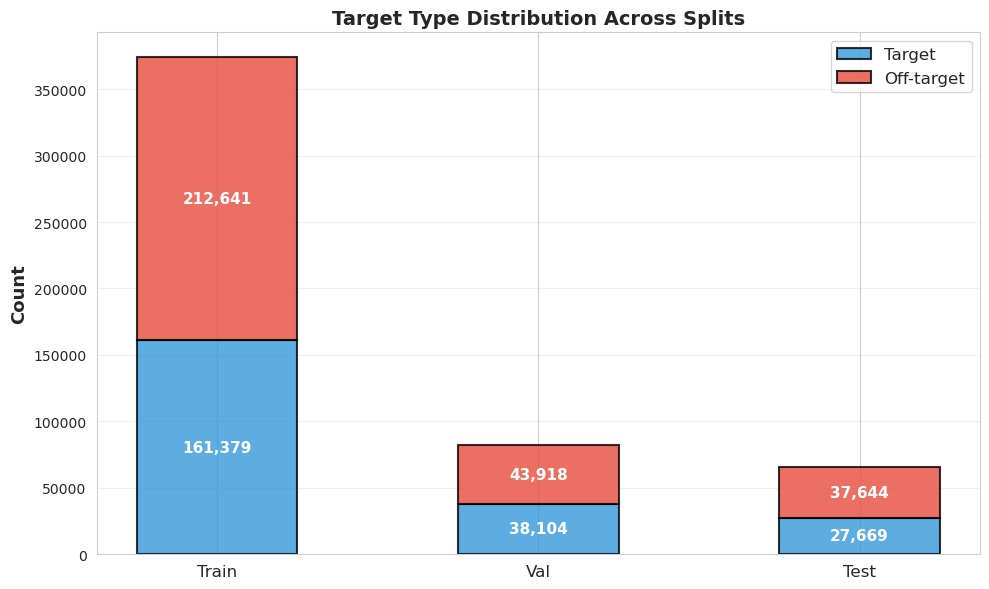


3️⃣ Creating data source distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_data_source_distribution.png


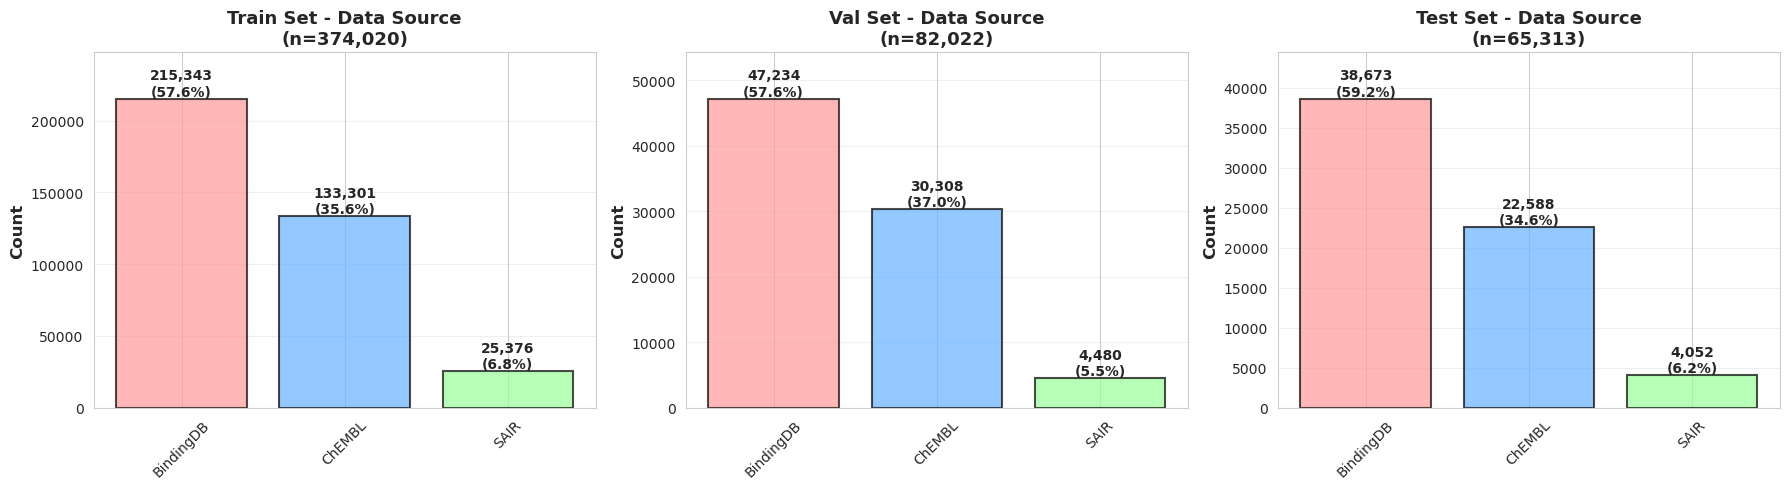


4️⃣ Creating stacked data source comparison...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_data_source_stacked.png


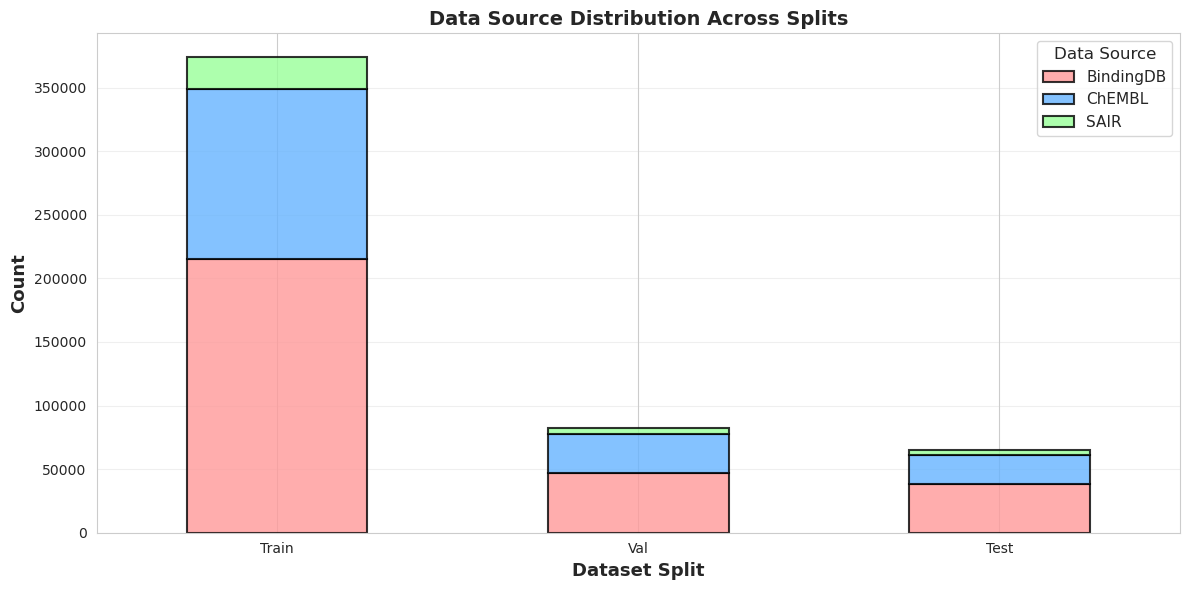


5️⃣ Creating protein-ligand pairs distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_pl_pairs_distribution.png


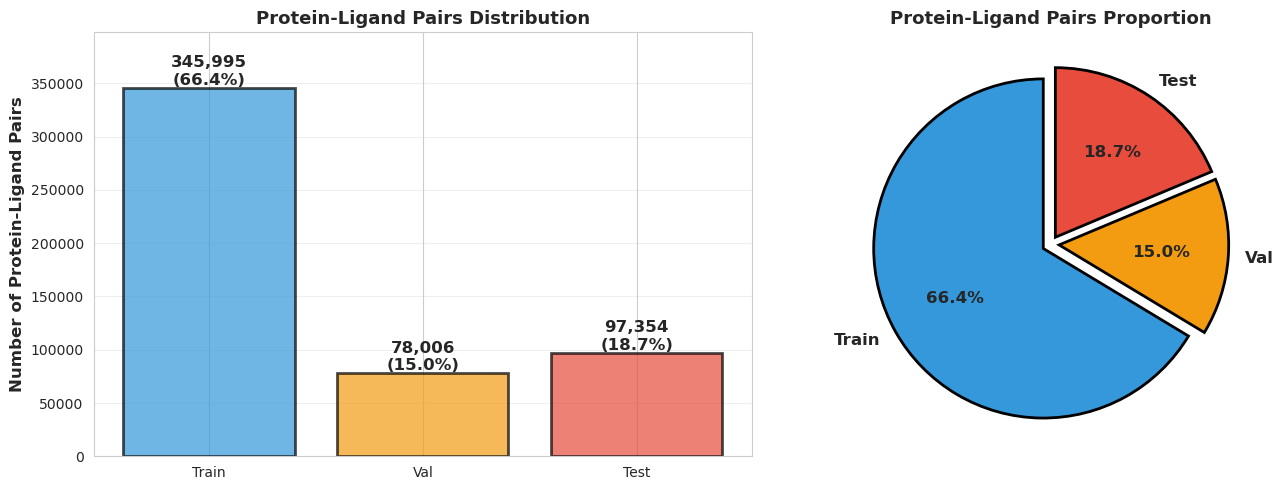


6️⃣ Creating unique proteins distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_unique_proteins_distribution.png


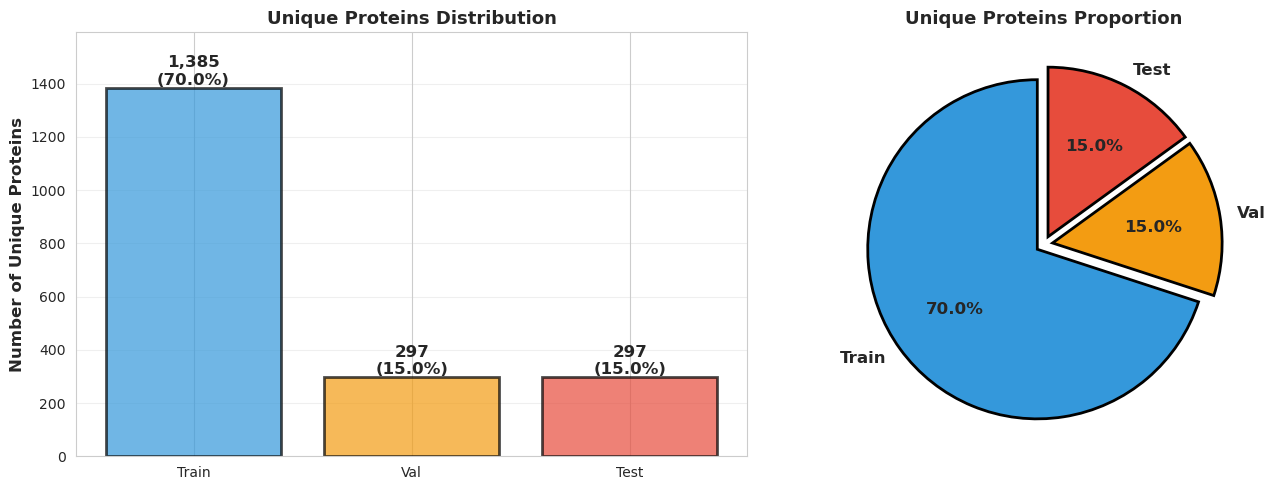


7️⃣ Creating unique ligands distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_unique_ligands_distribution.png


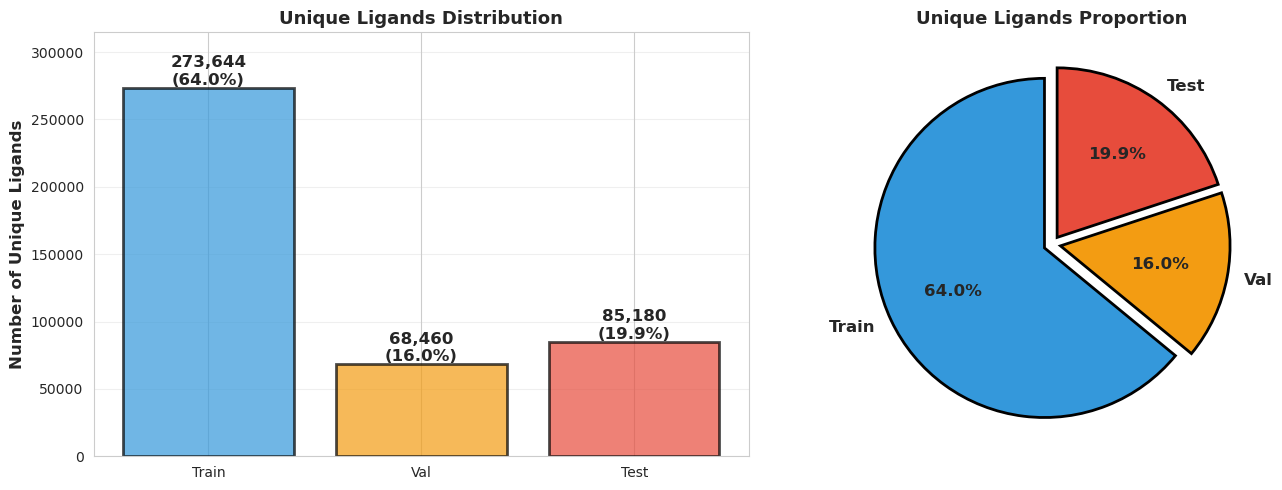


8️⃣ Creating comprehensive summary comparison...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_comprehensive_summary.png


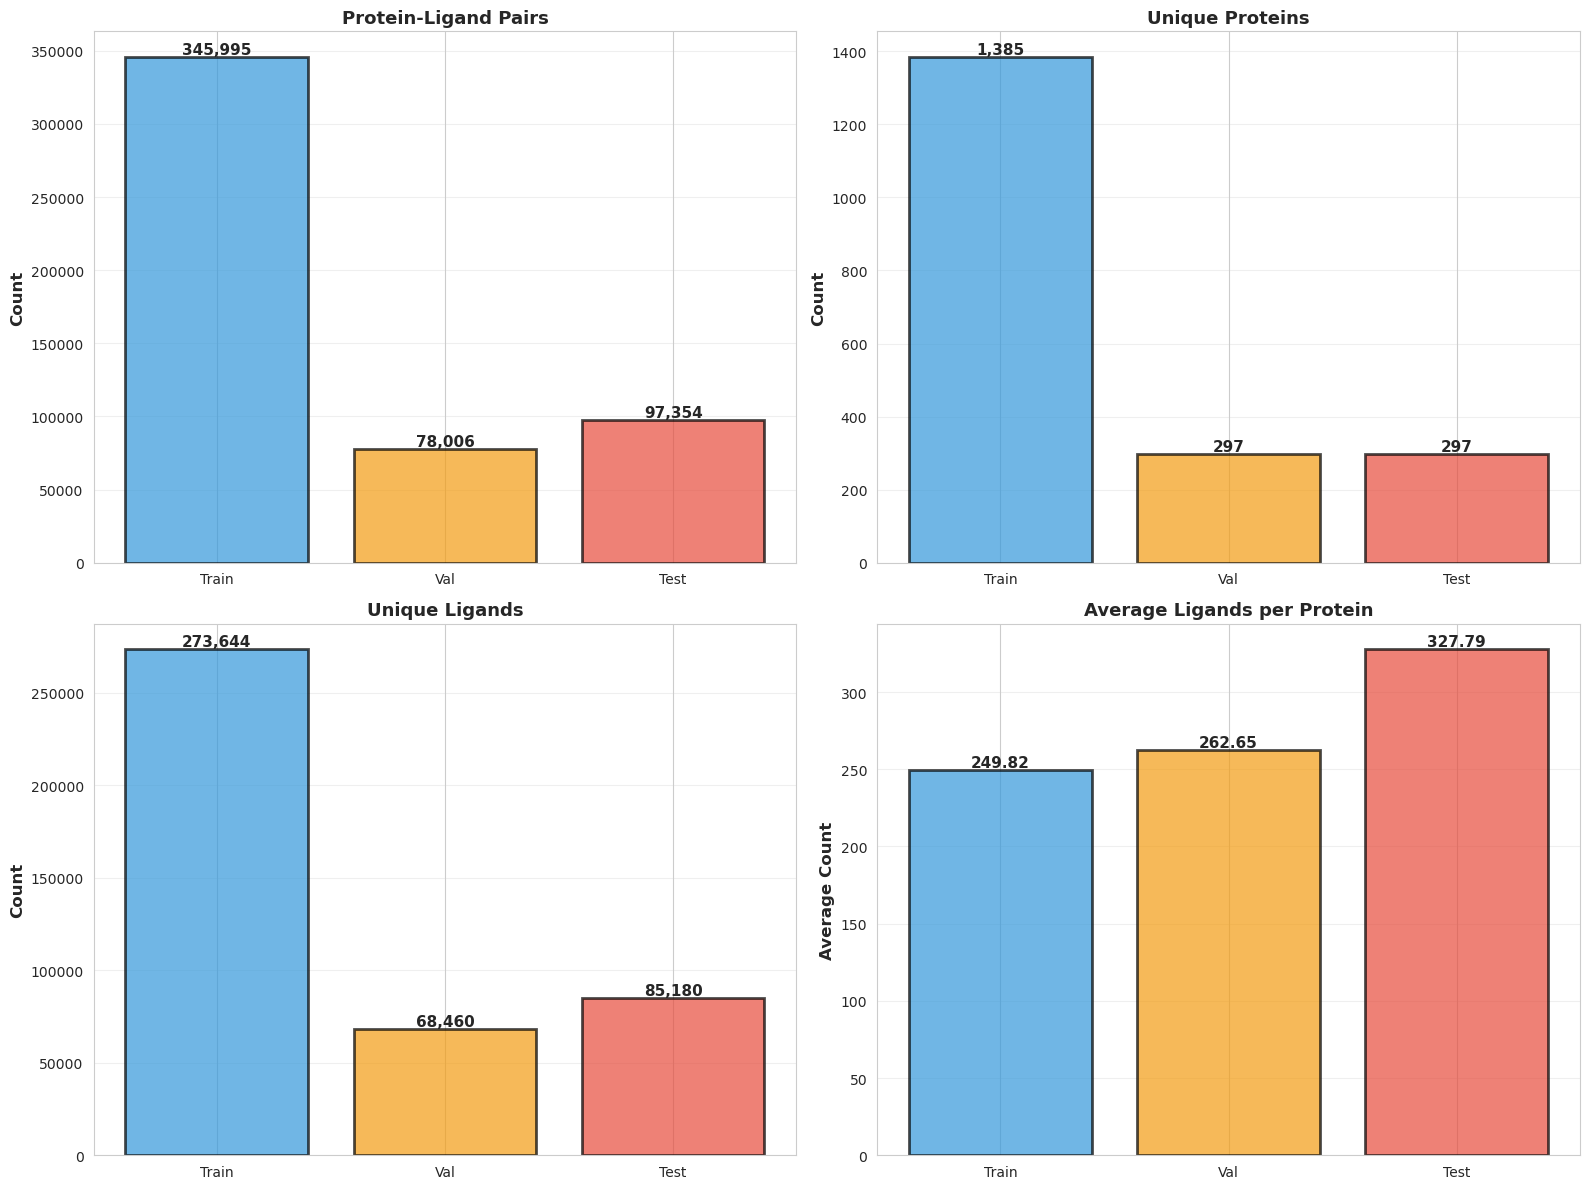


9️⃣ Creating summary statistics table...
✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_summary_table.png


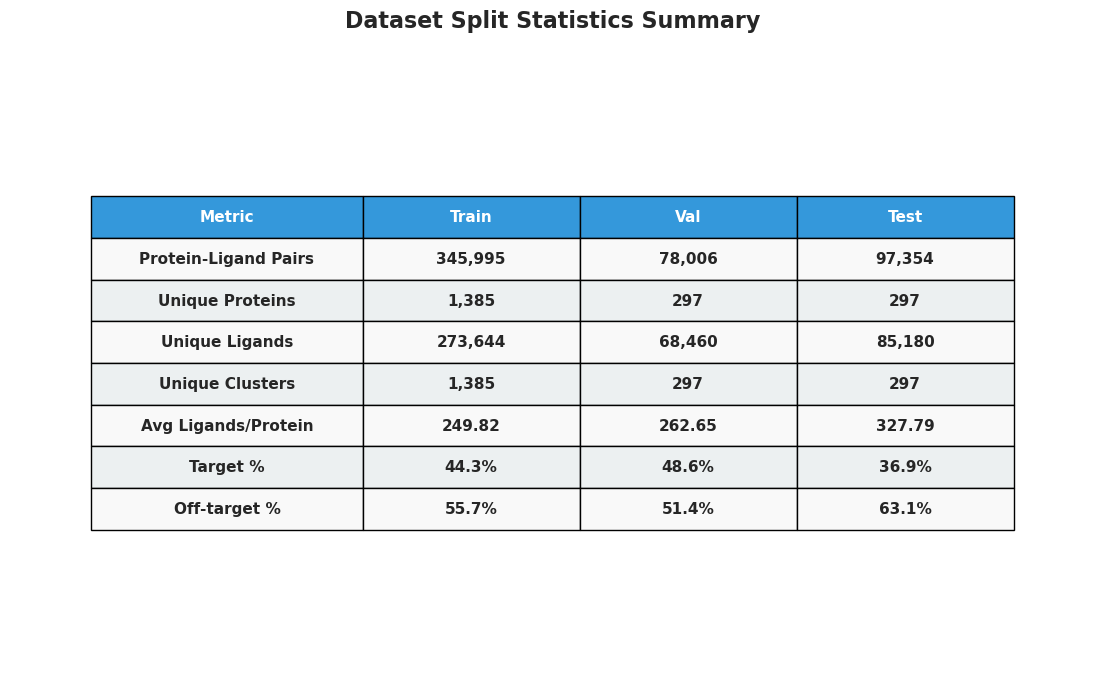


SUMMARY STATISTICS
              Metric   Train    Val   Test
Protein-Ligand Pairs 345,995 78,006 97,354
     Unique Proteins   1,385    297    297
      Unique Ligands 273,644 68,460 85,180
     Unique Clusters   1,385    297    297
 Avg Ligands/Protein  249.82 262.65 327.79
            Target %   44.3%  48.6%  36.9%
        Off-target %   55.7%  51.4%  63.1%

All split distribution visualizations complete!
✅ Generated 9 visualization files:
   1. split_target_type_distribution.png - Individual target type bar charts
   2. split_target_type_stacked.png - Stacked target type comparison
   3. split_data_source_distribution.png - Individual data source bar charts
   4. split_data_source_stacked.png - Stacked data source comparison
   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)
   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)
   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)
   8. split_comprehensive_summary.png -

In [ ]:
print("\n" + "=" * 80)
print("OPTIONAL: Creating comprehensive split distribution plots (stratified splitting)")
print("=" * 80)

train_proteins_strat = train_df_strat[['uniprot_id', 'sequence']].drop_duplicates()
val_proteins_strat = val_df_strat[['uniprot_id', 'sequence']].drop_duplicates()
test_proteins_strat = test_df_strat[['uniprot_id', 'sequence']].drop_duplicates()

# ========================================================================
# 1. Target Type Distribution across splits
# ========================================================================

print("\n1️⃣ Creating target type distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]):
    target_counts = split_df['target_type'].value_counts()
    colors = ['#3498db', '#e74c3c']
    
    bars = axes[idx].bar(target_counts.index, target_counts.values, 
                         color=colors[:len(target_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Target Type\n(n={len(split_df):,}) (Stratified)', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    axes[idx].set_ylim(0, max(target_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_target_type_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_target_type_distribution.png")
plt.show()

# ========================================================================
# 2. Target Type Distribution - Stacked Comparison
# ========================================================================

print("\n2️⃣ Creating stacked target type comparison...")

split_data = []
for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    target_counts = split_df['target_type'].value_counts()
    split_data.append({
        'split': split_name,
        'target': target_counts.get('target', 0),
        'off_target': target_counts.get('off_target', 0)
    })

split_df_vis = pd.DataFrame(split_data)
split_df_vis = split_df_vis.set_index('split')

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(split_df_vis))
width = 0.5

bars1 = ax.bar(x, split_df_vis['target'], width, label='Target', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, split_df_vis['off_target'], width, bottom=split_df_vis['target'],
               label='Off-target', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_title('Target Type Distribution Across Splits (Stratified)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_df_vis.index, fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_y() + height/2.,
                   f'{int(height):,}',
                   ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_target_type_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_target_type_stacked.png")
plt.show()

# ========================================================================
# 3. Data Source Distribution across splits
# ========================================================================

print("\n3️⃣ Creating data source distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]):
    source_counts = split_df['data_source'].value_counts()
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    bars = axes[idx].bar(source_counts.index, source_counts.values, 
                         color=colors[:len(source_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Data Source\n(n={len(split_df):,}) (Stratified)', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[idx].set_ylim(0, max(source_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_data_source_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_data_source_distribution.png")
plt.show()

# ========================================================================
# 4. Data Source Distribution - Stacked Comparison
# ========================================================================

print("\n4️⃣ Creating stacked data source comparison...")

split_source_data = {}
for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    source_counts = split_df['data_source'].value_counts()
    split_source_data[split_name] = source_counts

split_source_df = pd.DataFrame(split_source_data).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

split_source_df.T.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#ff9999', '#66b3ff', '#99ff99'],
                       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
ax.set_title('Data Source Distribution Across Splits (Stratified)', fontsize=14, fontweight='bold')
ax.legend(title='Data Source', fontsize=11, title_fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_data_source_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_data_source_stacked.png")
plt.show()

# ========================================================================
# 5. Protein-Ligand Pairs Distribution
# ========================================================================

print("\n5️⃣ Creating protein-ligand pairs distribution plots...")

pairs_data = {
    'Train': len(train_df),
    'Val': len(val_df),
    'Test': len(test_df)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(pairs_data.keys())
counts = list(pairs_data.values())
colors_split = ['#3498db', '#f39c12', '#e74c3c']

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Protein-Ligand Pairs', fontsize=12, fontweight='bold')
axes[0].set_title('Protein-Ligand Pairs Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Protein-Ligand Pairs Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_pl_pairs_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_pl_pairs_distribution.png")
plt.show()

# ========================================================================
# 6. Unique Proteins Distribution
# ========================================================================

print("\n6️⃣ Creating unique proteins distribution plots...")

proteins_data = {
    'Train': len(train_proteins_strat),
    'Val': len(val_proteins_strat),
    'Test': len(test_proteins_strat)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(proteins_data.keys())
counts = list(proteins_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Proteins', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Proteins Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Proteins Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_unique_proteins_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_unique_proteins_distribution.png")
plt.show()

# ========================================================================
# 7. Unique Ligands Distribution
# ========================================================================

print("\n7️⃣ Creating unique ligands distribution plots...")

ligands_data = {
    'Train': train_df_strat['ligand_smiles'].nunique(),
    'Val': val_df_strat['ligand_smiles'].nunique(),
    'Test': test_df_strat['ligand_smiles'].nunique()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(ligands_data.keys())
counts = list(ligands_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Ligands', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Ligands Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Ligands Proportion (Stratified)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_unique_ligands_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_unique_ligands_distribution.png")
plt.show()

# ========================================================================
# 8. Comprehensive Summary Comparison
# ========================================================================

print("\n8️⃣ Creating comprehensive summary comparison...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 8.1 Protein-Ligand Pairs
pairs_data = [len(train_df_strat), len(val_df_strat), len(test_df_strat)]
bars = axes[0, 0].bar(['Train', 'Val', 'Test'], pairs_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Protein-Ligand Pairs (Stratified)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, pairs_data):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.2 Unique Proteins
proteins_data = [len(train_proteins_strat), len(val_proteins_strat), len(test_proteins_strat)]
bars = axes[0, 1].bar(['Train', 'Val', 'Test'], proteins_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Unique Proteins (Stratified)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, proteins_data):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.3 Unique Ligands
ligands_data = [train_df_strat['ligand_smiles'].nunique(), 
                val_df_strat['ligand_smiles'].nunique(),
                test_df_strat['ligand_smiles'].nunique()]
bars = axes[1, 0].bar(['Train', 'Val', 'Test'], ligands_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Unique Ligands (Stratified)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ligands_data):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.4 Ligands per Protein (Average)
avg_ligands = [
    len(train_df_strat) / len(train_proteins_strat),
    len(val_df_strat) / len(val_proteins_strat),
    len(test_df_strat) / len(test_proteins_strat)
]
bars = axes[1, 1].bar(['Train', 'Val', 'Test'], avg_ligands, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Count', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Ligands per Protein (Stratified)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, avg_ligands):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_comprehensive_summary.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_comprehensive_summary.png")
plt.show()

# ========================================================================
# 9. Summary Statistics Table
# ========================================================================

print("\n9️⃣ Creating summary statistics table...")

summary_stats = pd.DataFrame({
    'Metric': [
        'Protein-Ligand Pairs',
        'Unique Proteins',
        'Unique Ligands',
        'Unique Clusters',
        'Avg Ligands/Protein',
        'Target %',
        'Off-target %'
    ],
    'Train': [
        f"{len(train_df):,}",
        f"{len(train_proteins):,}",
        f"{train_df['ligand_smiles'].nunique():,}",
        f"{len(train_clusters):,}",
        f"{len(train_df) / len(train_proteins):.2f}",
        f"{(train_df['target_type'] == 'target').sum() / len(train_df) * 100:.1f}%",
        f"{(train_df['target_type'] == 'off_target').sum() / len(train_df) * 100:.1f}%"
    ],
    'Val': [
        f"{len(val_df):,}",
        f"{len(val_proteins):,}",
        f"{val_df['ligand_smiles'].nunique():,}",
        f"{len(val_clusters):,}",
        f"{len(val_df) / len(val_proteins):.2f}",
        f"{(val_df['target_type'] == 'target').sum() / len(val_df) * 100:.1f}%",
        f"{(val_df['target_type'] == 'off_target').sum() / len(val_df) * 100:.1f}%"
    ],
    'Test': [
        f"{len(test_df):,}",
        f"{len(test_proteins):,}",
        f"{test_df['ligand_smiles'].nunique():,}",
        f"{len(test_clusters):,}",
        f"{len(test_df) / len(test_proteins):.2f}",
        f"{(test_df['target_type'] == 'target').sum() / len(test_df) * 100:.1f}%",
        f"{(test_df['target_type'] == 'off_target').sum() / len(test_df) * 100:.1f}%"
    ]
})

# Create figure with table
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_stats.values, 
                colLabels=summary_stats.columns,
                cellLoc='center', loc='center',
                colWidths=[0.25, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_stats) + 1):
    for j in range(len(summary_stats.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#f9f9f9')
        table[(i, j)].set_text_props(weight='bold')

plt.title('Dataset Split Statistics Summary (Stratified)', fontsize=16, fontweight='bold', pad=20)
plt.savefig('/scratch/yunmin/data/graph/train/plots/stratified/split_summary_table.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/plots/stratified/split_summary_table.png")
plt.show()

# Print table to console
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_stats.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("All split distribution visualizations complete!")
print("=" * 80)
print(f"✅ Generated 9 visualization files:")
print(f"   1. split_target_type_distribution.png - Individual target type bar charts")
print(f"   2. split_target_type_stacked.png - Stacked target type comparison")
print(f"   3. split_data_source_distribution.png - Individual data source bar charts")
print(f"   4. split_data_source_stacked.png - Stacked data source comparison")
print(f"   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)")
print(f"   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)")
print(f"   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)")
print(f"   8. split_comprehensive_summary.png - 2x2 summary comparison")
print(f"   9. split_summary_table.png - Statistics table")

### Visualize clusters using t-SNE and PCA


VISUALIZING CLUSTERS: t-SNE and PCA

1️⃣ Encoding sequences...
Computing k-mer frequencies...
  - Total unique 3-mers: 8,020
  - K-mer matrix shape: (1979, 8020)
✅ Sequences encoded and scaled
  - Unique clusters: 1979

2️⃣ Computing PCA...
  - PCA variance explained: 6.1%
  - PC1: 5.2%
  - PC2: 1.0%
✅ Saved: /scratch/yunmin/data/graph/train/cluster_pca.png


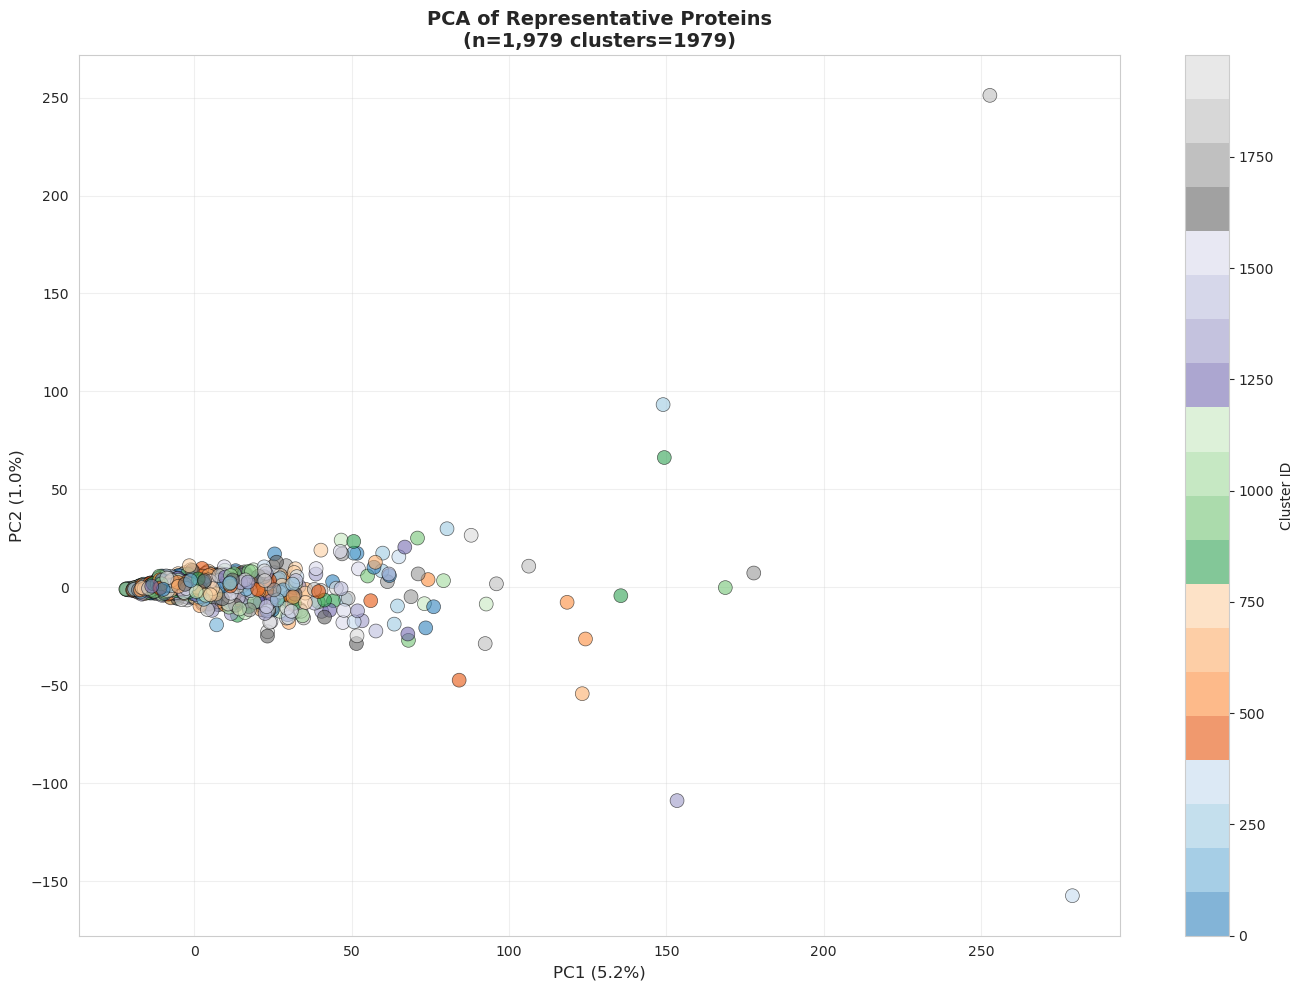


3️⃣ Computing t-SNE...
  (This may take a few minutes for large datasets)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1979 samples in 0.001s...
[t-SNE] Computed neighbors for 1979 samples in 0.153s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1979
[t-SNE] Computed conditional probabilities for sample 1979 / 1979
[t-SNE] Mean sigma: 3.096642
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.965363
[t-SNE] KL divergence after 1000 iterations: 1.498105
✅ t-SNE completed
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne.png


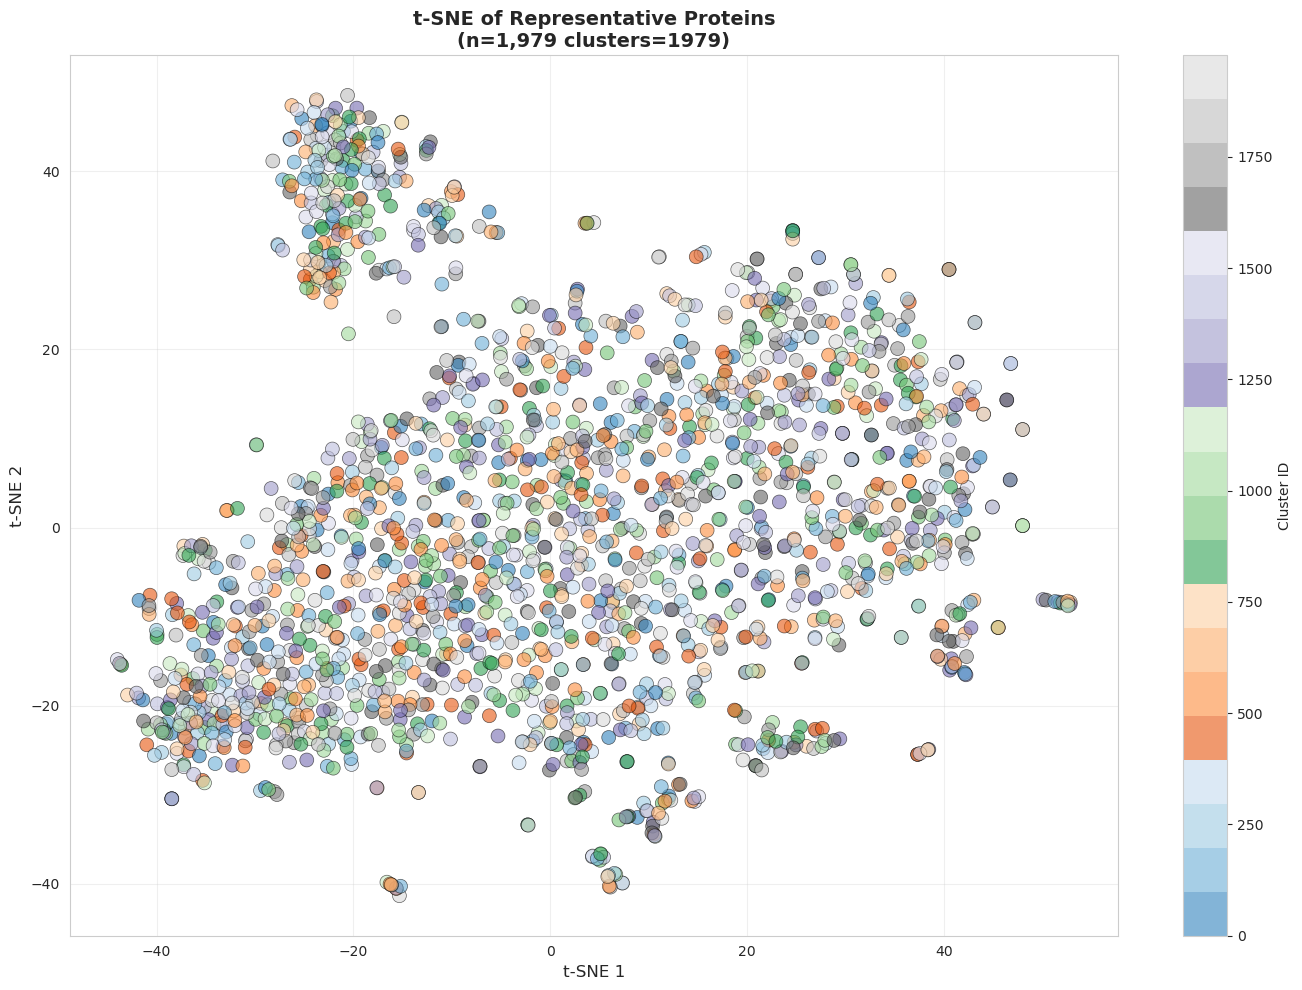


4️⃣ Visualizing Train/Val/Test splits on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_splits.png


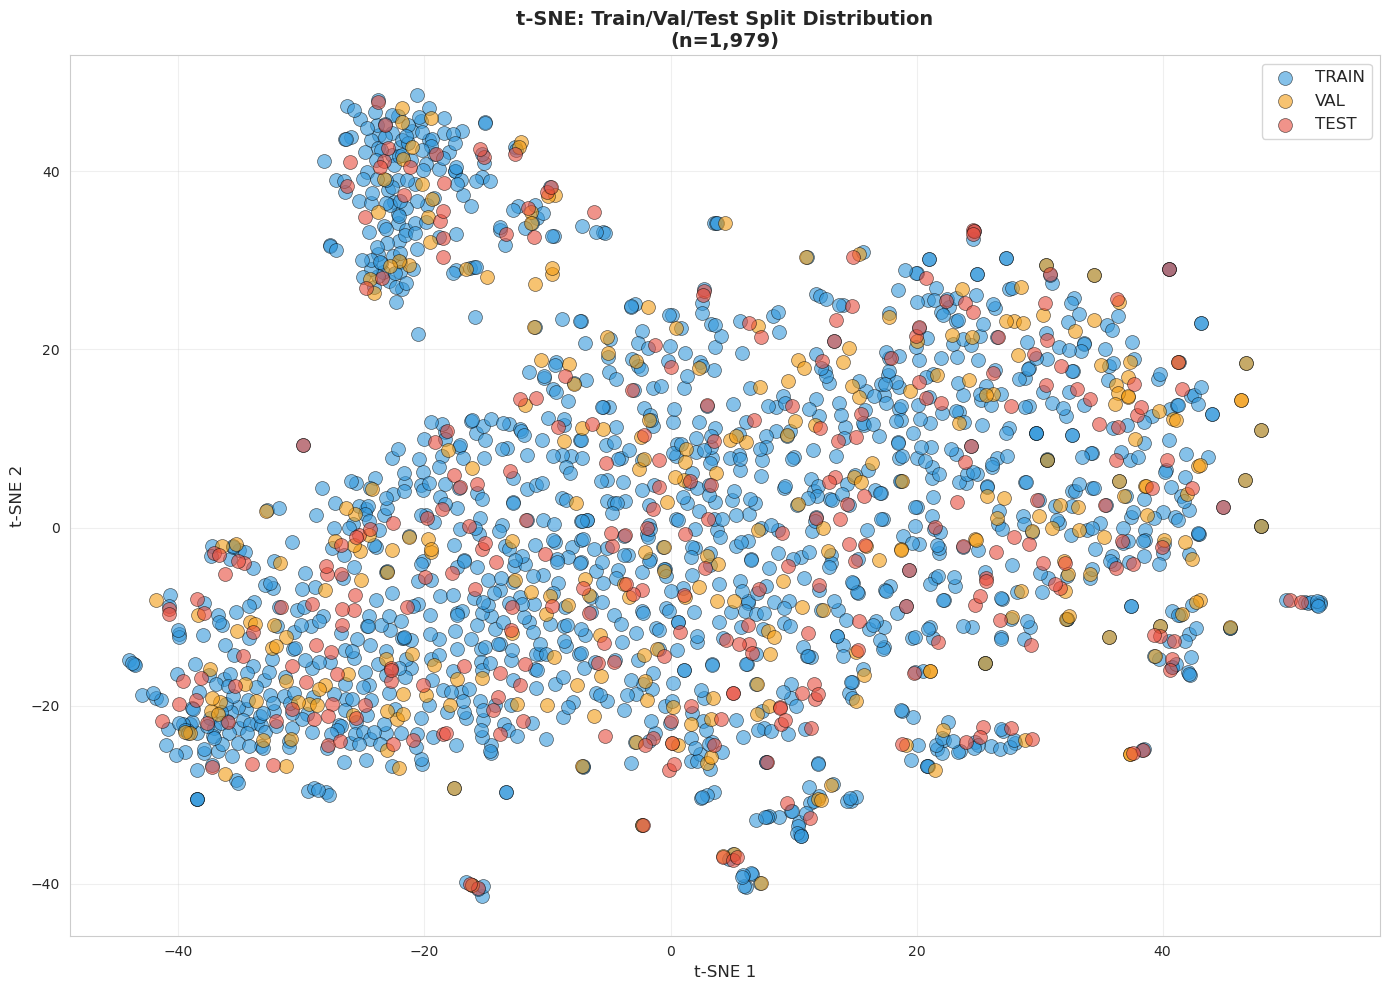


5️⃣ Visualizing cluster sizes on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_sizes.png


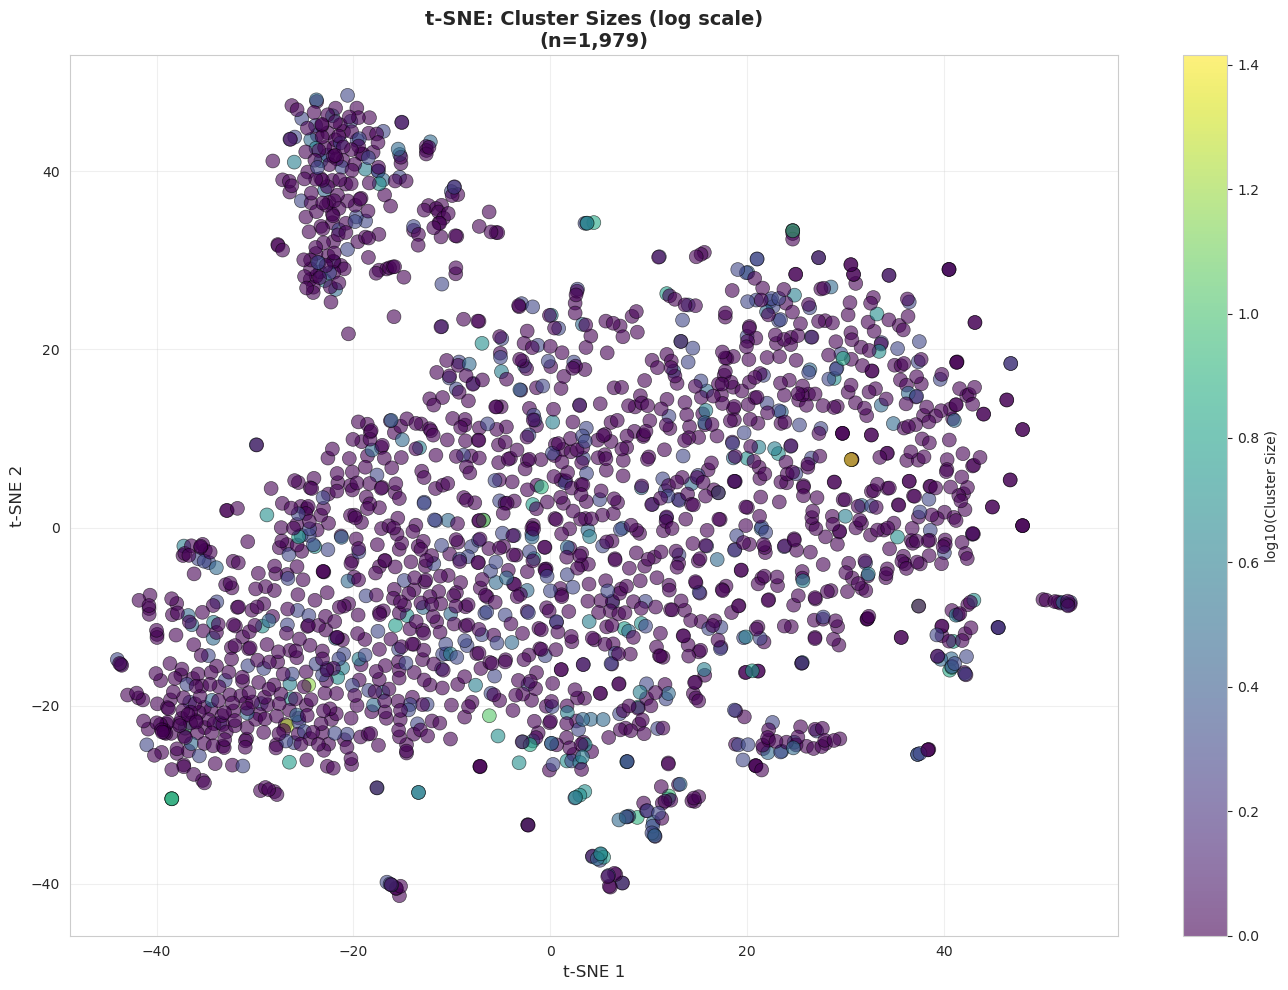


6️⃣ Visualizing sequence length on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png


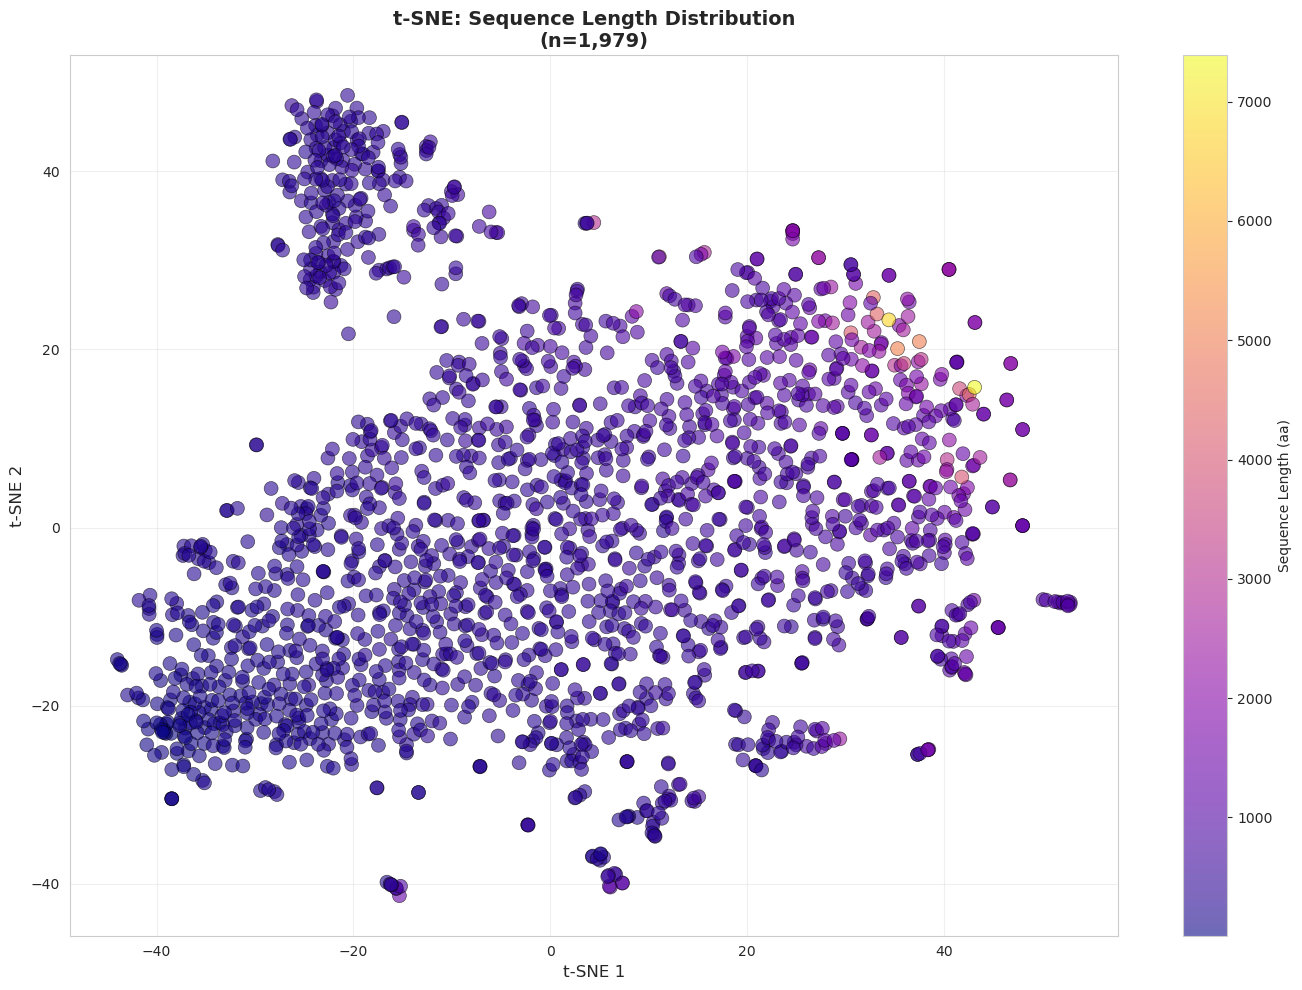


7️⃣ Creating comparison figure...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png


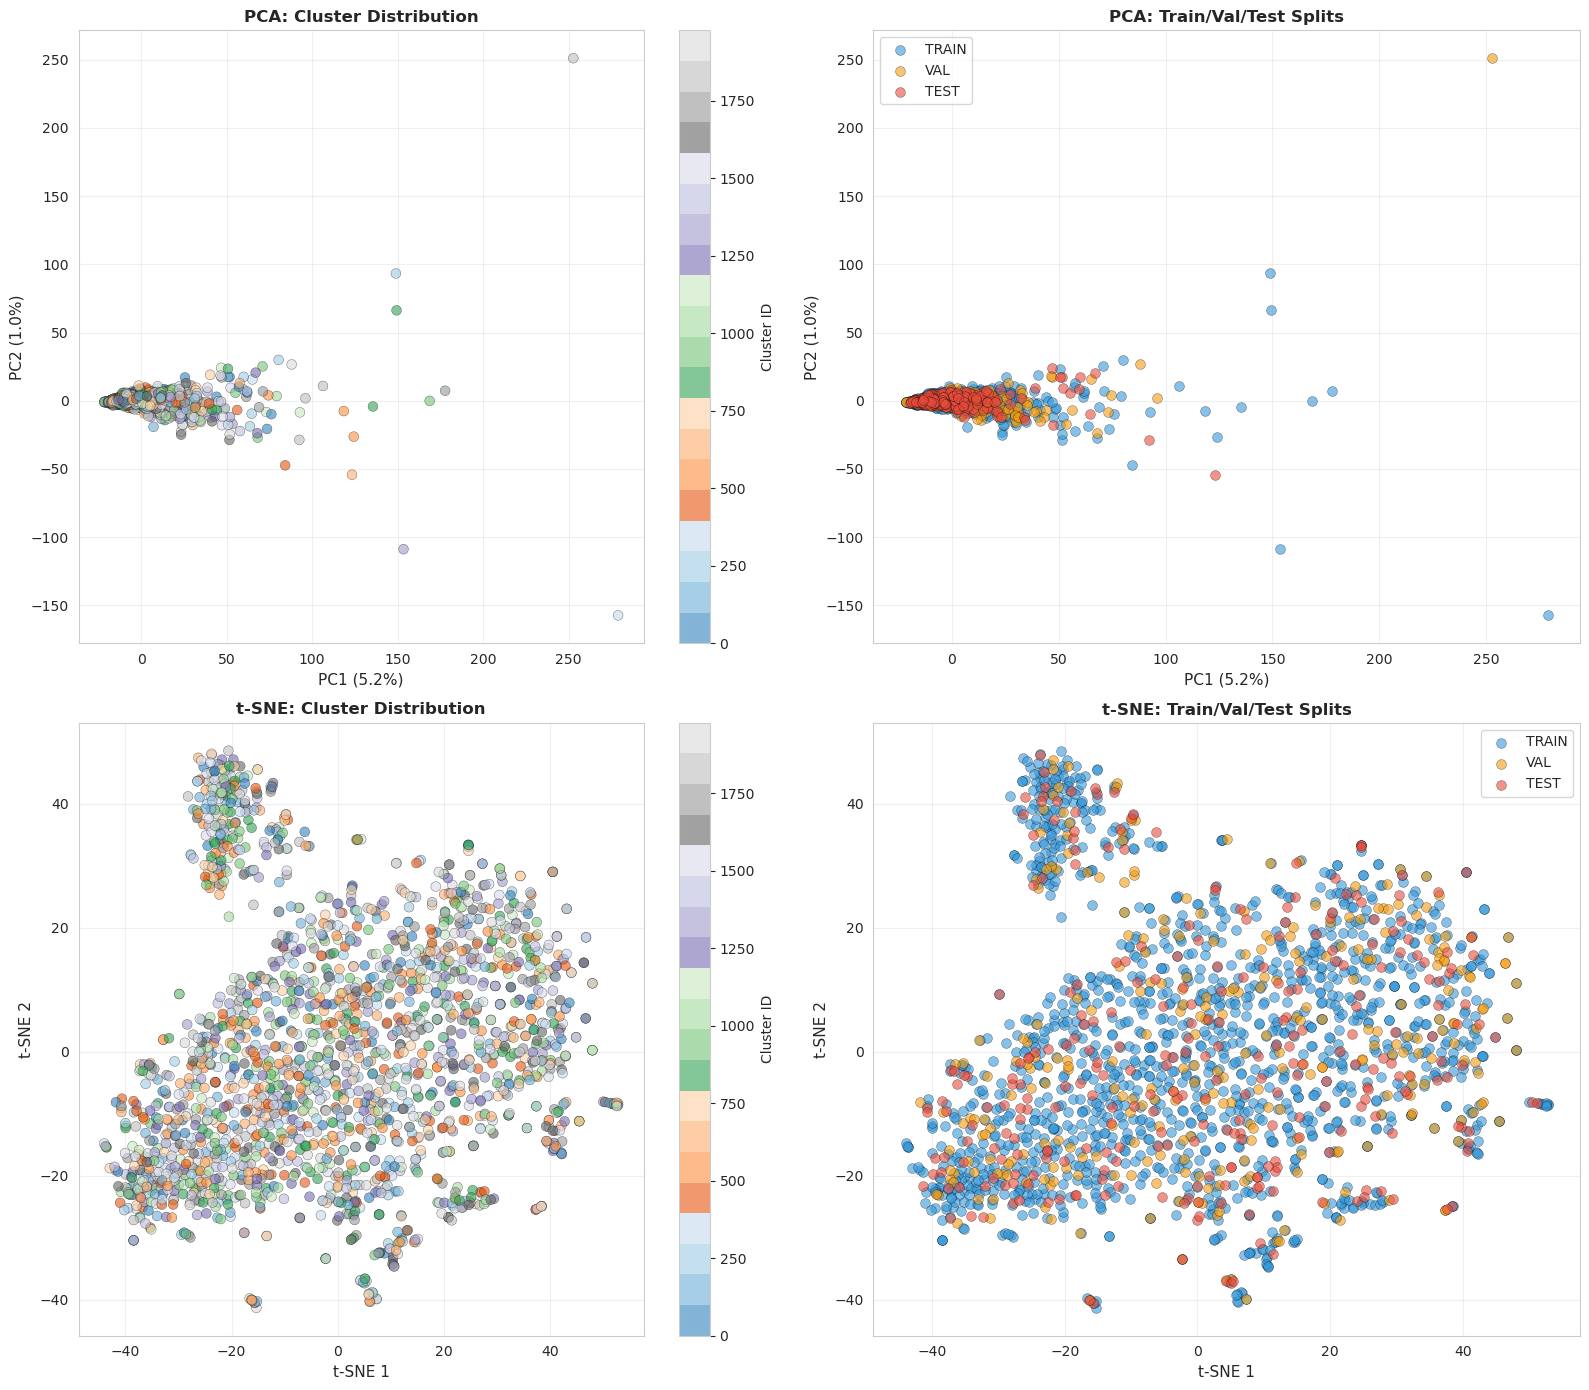


All cluster visualizations complete!
✅ Generated 7 visualization files:
   1. cluster_pca.png - PCA of all clusters
   2. cluster_tsne.png - t-SNE of all clusters
   3. cluster_tsne_splits.png - t-SNE colored by train/val/test
   4. cluster_tsne_sizes.png - t-SNE colored by cluster size
   5. cluster_tsne_seqlen.png - t-SNE colored by sequence length
   6. cluster_comparison_pca_tsne.png - 2x2 comparison figure


In [113]:
# ========================================================================
# OPTIONAL: Visualize clusters using t-SNE and PCA
# ========================================================================

print("\n" + "=" * 80)
print("VISUALIZING CLUSTERS: t-SNE and PCA")
print("=" * 80)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Convert sequences to numerical embeddings using ProtT5 or simple encoding
print("\n1️⃣ Encoding sequences...")

def encode_sequence_kmer(sequence, k=3):
    """Simple k-mer encoding of protein sequence"""
    kmers = {}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        kmers[kmer] = kmers.get(kmer, 0) + 1
    return kmers

def get_kmer_vector(sequence, all_kmers, k=3):
    """Convert sequence to k-mer frequency vector"""
    kmers = encode_sequence_kmer(sequence, k)
    vector = [kmers.get(kmer, 0) for kmer in all_kmers]
    return vector

# Get all unique 3-mers from representative proteins
print("Computing k-mer frequencies...")
all_kmers = set()
for seq in representative_proteins['sequence']:
    for i in range(len(seq) - 2):
        all_kmers.add(seq[i:i+3])

all_kmers = sorted(list(all_kmers))
print(f"  - Total unique 3-mers: {len(all_kmers):,}")

# Create k-mer vectors for all representative proteins
kmer_vectors = []
for seq in representative_proteins['sequence']:
    kmer_vectors.append(get_kmer_vector(seq, all_kmers, k=3))

X_kmers = np.array(kmer_vectors)
print(f"  - K-mer matrix shape: {X_kmers.shape}")

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmers)
print(f"✅ Sequences encoded and scaled")

# Get cluster IDs for colors
cluster_ids = representative_proteins['cluster_id'].values
print(f"  - Unique clusters: {len(np.unique(cluster_ids))}")

# ========================================================================
# PCA Visualization
# ========================================================================

print("\n2️⃣ Computing PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"  - PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(14, 10))

# Create scatter plot
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_ids, cmap='tab20c', s=100, alpha=0.6, edgecolors='black', linewidth=0.5
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title(f'PCA of Representative Proteins\n(n={len(representative_proteins):,} clusters={len(np.unique(cluster_ids))})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_pca.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_pca.png")
plt.show()

# ========================================================================
# t-SNE Visualization (with perplexity optimization)
# ========================================================================

print("\n3️⃣ Computing t-SNE...")
print("  (This may take a few minutes for large datasets)")

# Use PCA as preprocessing for t-SNE (faster)
X_pca_50 = PCA(n_components=50).fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_SEED,
    perplexity=min(30, (len(representative_proteins) - 1) // 3),
    max_iter=1000,
    verbose=1
)
X_tsne = tsne.fit_transform(X_pca_50)

print(f"✅ t-SNE completed")

fig, ax = plt.subplots(figsize=(14, 10))

# Create scatter plot
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=cluster_ids, cmap='tab20c', s=100, alpha=0.6, edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE of Representative Proteins\n(n={len(representative_proteins):,} clusters={len(np.unique(cluster_ids))})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne.png")
plt.show()

# ========================================================================
# Train/Val/Test Split Visualization (t-SNE)
# ========================================================================

print("\n4️⃣ Visualizing Train/Val/Test splits on t-SNE...")

# Map cluster IDs to split assignments
cluster_to_split = pd.DataFrame({
    'cluster_id': list(train_clusters) + list(val_clusters) + list(test_clusters),
    'split': ['train'] * len(train_clusters) + ['val'] * len(val_clusters) + ['test'] * len(test_clusters)
}).set_index('cluster_id')['split'].to_dict()

split_labels = representative_proteins['cluster_id'].map(cluster_to_split)

# Create color mapping
split_colors = {'train': '#3498db', 'val': '#f39c12', 'test': '#e74c3c'}
split_color_array = [split_colors[s] for s in split_labels]

fig, ax = plt.subplots(figsize=(14, 10))

for split in ['train', 'val', 'test']:
    mask = split_labels == split
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=split_colors[split], s=100, alpha=0.6,
        edgecolors='black', linewidth=0.5, label=split.upper()
    )

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Train/Val/Test Split Distribution\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_splits.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_splits.png")
plt.show()

# ========================================================================
# Cluster Size Heatmap on t-SNE
# ========================================================================

print("\n5️⃣ Visualizing cluster sizes on t-SNE...")

# Get cluster sizes
cluster_sizes_map = {cid: len(members) for cid, members in clusters.items()}
sizes = representative_proteins['cluster_id'].map(cluster_sizes_map)

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=np.log10(sizes), cmap='viridis', s=100, alpha=0.6,
    edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Cluster Sizes (log scale)\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='log10(Cluster Size)')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_sizes.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_sizes.png")
plt.show()

# ========================================================================
# Sequence Length on t-SNE
# ========================================================================

print("\n6️⃣ Visualizing sequence length on t-SNE...")

seq_lengths = representative_proteins['sequence_length'].values

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=seq_lengths, cmap='plasma', s=100, alpha=0.6,
    edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Sequence Length Distribution\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='Sequence Length (aa)')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png")
plt.show()

# ========================================================================
# Summary comparison figure
# ========================================================================

print("\n7️⃣ Creating comparison figure...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# PCA - Clusters
scatter1 = axes[0, 0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_ids, cmap='tab20c', s=50, alpha=0.6, edgecolors='black', linewidth=0.3
)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 0].set_title('PCA: Cluster Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster ID')

# PCA - Splits
for split in ['train', 'val', 'test']:
    mask = split_labels == split
    axes[0, 1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=split_colors[split], s=50, alpha=0.6,
        edgecolors='black', linewidth=0.3, label=split.upper()
    )
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 1].set_title('PCA: Train/Val/Test Splits', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# t-SNE - Clusters
scatter3 = axes[1, 0].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=cluster_ids, cmap='tab20c', s=50, alpha=0.6, edgecolors='black', linewidth=0.3
)
axes[1, 0].set_xlabel('t-SNE 1', fontsize=11)
axes[1, 0].set_ylabel('t-SNE 2', fontsize=11)
axes[1, 0].set_title('t-SNE: Cluster Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster ID')

# t-SNE - Splits
for split in ['train', 'val', 'test']:
    mask = split_labels == split
    axes[1, 1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=split_colors[split], s=50, alpha=0.6,
        edgecolors='black', linewidth=0.3, label=split.upper()
    )
axes[1, 1].set_xlabel('t-SNE 1', fontsize=11)
axes[1, 1].set_ylabel('t-SNE 2', fontsize=11)
axes[1, 1].set_title('t-SNE: Train/Val/Test Splits', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png")
plt.show()

print("\n" + "=" * 80)
print("All cluster visualizations complete!")
print("=" * 80)
print(f"✅ Generated 7 visualization files:")
print(f"   1. cluster_pca.png - PCA of all clusters")
print(f"   2. cluster_tsne.png - t-SNE of all clusters")
print(f"   3. cluster_tsne_splits.png - t-SNE colored by train/val/test")
print(f"   4. cluster_tsne_sizes.png - t-SNE colored by cluster size")
print(f"   5. cluster_tsne_seqlen.png - t-SNE colored by sequence length")
print(f"   6. cluster_comparison_pca_tsne.png - 2x2 comparison figure")